In [7]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from properscoring import crps_ensemble
import os
import sys
import calendar

In [8]:
# Add the path to the src directory (two levels up)
sys.path.append(os.path.abspath('../../'))
from src.data_loader import DataLoader
from src.data_processor import CFSTransformer, CNBSForecaster, ForecastTransformer
from src.database_utils import CFSDatabase
from src.data_processor import SeasonalCycleProcessor

In [9]:
# Directory where the repository is cloned
local_path = '/Users/ljob/Desktop/'

# Path to data directory
input_dir = local_path + 'cnbs-predictor/data/'

# Path to input CFS forecast database
cfs_database = local_path+ 'Data/cfs_forecast_archive_2011-2026.db'
cfs_table = 'cfs_forecast_data'

# Path to save CNBS forecast output to a database
cnbs_database = local_path + 'Data/cnbs_forecast_verification.db'
cnbs_table = 'cnbs_forecast'

# Path to GLSEA SST data
glsea_data = input_dir + 'glsea/oisst_sst_1981-2024.csv'

# Path to saved scalers
model_dir = input_dir + "input/models/"
scaler_dir = input_dir + "input/scalers/"
clim_dir = input_dir + "input/climatology/"

# List of models to run
models_list = ['GP', 'RF', 'NN', 'XGB']

In [10]:
# Load CFS forecast data from the database and format it before predicting CNBS
data = CFSDatabase(cfs_database, cfs_table).load()

In [11]:
scp_X, scp_y = SeasonalCycleProcessor.load_clim(clim_dir)
scp_y.climatology.columns = [
    c.replace("_target", "") for c in scp_y.climatology.columns
]

In [12]:
X = CFSTransformer(data).structure_input("anomaly", scp_X)

In [13]:
# Load in GLSEA SST data and merge with features
dataloader = DataLoader()
df_sst_k = dataloader.glsea(input_dir + 'glsea/oisst_sst_1981-2024.csv', units='K')

df_sst_expanded = df_sst_k.reindex(X.index, method="ffill")
X_sst = df_sst_expanded.join(X).dropna()

In [14]:
eri_lake = 18596.39
eri_land = 81902.18
ont_lake = 15569.25
ont_land = 64465.19
mih_lake = 123626.28
mih_land = 236478.94
sup_lake = 78288.65
sup_land = 123736.05

mic_land = 118000.00
hur_land = 134100.00


snodas_data = pd.read_csv(local_path+'DoD SAFE-8WBhd9qAMBPtYPKG/Snodas/SWE.SNODAS.GL.csv',sep=',', skiprows=5)
snodas_data['date'] = pd.to_datetime(snodas_data[['year', 'month', 'day']])
snodas_data['michigan-huron_snodas'] = (snodas_data['MIC']*mic_land + snodas_data['HUR']*hur_land) / (mih_land)
snodas_data = snodas_data.rename(columns={
    'SUP': 'superior_snodas',
    'ERI': 'erie_snodas',
    'ONT': 'ontario_snodas'
})
snodas = snodas_data[[
    'date',
    'superior_snodas',
    'michigan-huron_snodas',
    'erie_snodas',
    'ontario_snodas'
]]
snodas.set_index('date', inplace=True)

aligned_snodas, aligned_X_merged = snodas.align(X_sst, join='inner', axis=0)
#snodas_shifted = CFSProcessor.shift_variables(aligned_snodas, lag=3, lead=0)
#print(snodas_shifted)

X_merged = pd.merge(aligned_snodas, aligned_X_merged, left_index=True, right_index=True, how='inner')
print(X_merged)

            superior_snodas  michigan-huron_snodas   erie_snodas  \
2011-04-01     1.220020e+02           6.250837e+01  6.993540e+00   
2011-04-02     1.226820e+02           6.008892e+01  3.838240e+00   
2011-04-03     1.216890e+02           5.607686e+01  1.483410e+00   
2011-04-04     1.262070e+02           5.724212e+01  1.368400e+00   
2011-04-05     1.350030e+02           5.451844e+01  2.599490e-01   
...                     ...                    ...           ...   
2025-05-17     2.745150e-10           1.845750e-10  1.086560e-10   
2025-05-18     2.316850e-03           1.845750e-10  1.086560e-10   
2025-05-19     2.433830e-02           5.440795e-04  1.086560e-10   
2025-05-20     2.745150e-10           1.845750e-10  1.086560e-10   
2025-05-21     2.745150e-10           1.845750e-10  1.086560e-10   

            ontario_snodas  superior_sst  michigan-huron_sst  erie_sst  \
2011-04-01    3.218580e+01        273.60              274.36    274.08   
2011-04-02    3.094100e+01        2

In [15]:
print(X_merged)

            superior_snodas  michigan-huron_snodas   erie_snodas  \
2011-04-01     1.220020e+02           6.250837e+01  6.993540e+00   
2011-04-02     1.226820e+02           6.008892e+01  3.838240e+00   
2011-04-03     1.216890e+02           5.607686e+01  1.483410e+00   
2011-04-04     1.262070e+02           5.724212e+01  1.368400e+00   
2011-04-05     1.350030e+02           5.451844e+01  2.599490e-01   
...                     ...                    ...           ...   
2025-05-17     2.745150e-10           1.845750e-10  1.086560e-10   
2025-05-18     2.316850e-03           1.845750e-10  1.086560e-10   
2025-05-19     2.433830e-02           5.440795e-04  1.086560e-10   
2025-05-20     2.745150e-10           1.845750e-10  1.086560e-10   
2025-05-21     2.745150e-10           1.845750e-10  1.086560e-10   

            ontario_snodas  superior_sst  michigan-huron_sst  erie_sst  \
2011-04-01    3.218580e+01        273.60              274.36    274.08   
2011-04-02    3.094100e+01        2

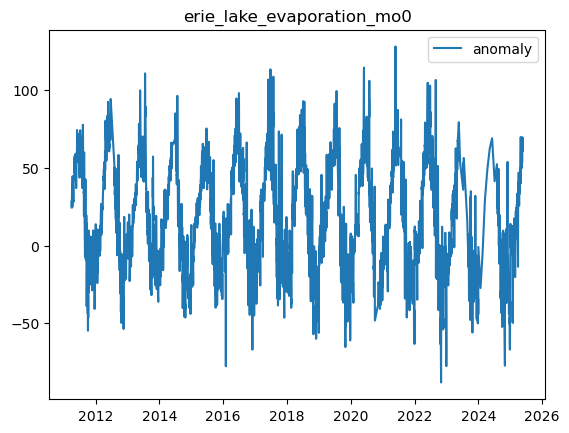

In [16]:
import matplotlib.pyplot as plt

var = "erie_lake_evaporation_mo0"

start_date = "2011-03-01"
end_date = "2026-01-01"

plt.figure()
plt.plot(X_merged.loc[start_date:end_date, var], label="anomaly")
plt.legend()
plt.title(var)
plt.show()

In [17]:
# Initialize model forecaster
model_runner = CNBSForecaster(model_dir, scaler_dir, "anom")

# Run predictions for each model
model_predictions = []
for model_name in model_runner.models.keys():
    print(f"Predicting with {model_name}...")
    df_y = model_runner.predict(X_merged, model_name, scp_y)
    model_predictions.append(df_y)

# Combine all predictions
df_all = pd.concat(model_predictions)#.reset_index()
#df_all["cfs_run"] = pd.to_datetime(df_all["cfs_run"]).dt.strftime("%Y%m%d%H")

/opt/miniconda3/envs/nbs_env/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/miniconda3/envs/nbs_env/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator GaussianProcessRegressor from version 1.8.0 when using version 1.7.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/miniconda3/envs/nbs_env/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from versi

Predicting with XGB...
Predicting with GP...
Predicting with NN...
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 348us/step
Predicting with RF...


In [18]:
df_all = df_all.reset_index()
df_all = df_all.rename(columns={"index": "cfs_run"})

# Step 1: Melt into long format
df_melted = df_all.melt(
    id_vars=['cfs_run', 'model'],
    var_name='variable',
    value_name='value'
)

# Step 2: Split into lake, variable, and month_offset
split_cols = df_melted['variable'].str.rsplit('_', n=2, expand=True)
df_melted['component'] = split_cols[0] + '_' + split_cols[1]
df_melted['month_offset'] = split_cols[2].str.replace('mo', '', regex=False).astype(int)

# Step 3: Compute forecast_month
df_melted['forecast_month'] = df_melted.apply(
    lambda row: (pd.to_datetime(row['cfs_run']) + pd.DateOffset(months=row['month_offset'])).strftime('%Y-%m'),
    axis=1
)
df_melted = df_melted.drop(columns=['month_offset'])

# Step 4: Pivot so each variable type is its own column
df_tidy = df_melted.pivot_table(
    index=['cfs_run', 'model', 'forecast_month'],
    columns='component',
    values='value'
).reset_index()
df_tidy.columns.name = None

df_tidy.to_csv('CNBS_forecast_ver.csv', sep='\t', index=False)

In [19]:
df_tidy["date"] = pd.to_datetime(df_tidy["forecast_month"], format="%Y-%m")

In [20]:
#transformer = ForecastTransformer(df_all)

#df_pivot = transformer.pivot()

In [21]:
# Save to a CSV [mm]
#df_pivot.to_csv('CNBS_forecast_ver.csv', sep='\t', index=False)

In [22]:
# Open and load observational data

l2_obs = DataLoader().l2swbm(input_dir + 'l2swbm/')
l2_obs = l2_obs.reset_index()

glcc_obs = DataLoader().glcc(input_dir + 'glcc/', 'mm')
glcc_obs = glcc_obs.reset_index()

In [23]:
# Merge on forecast_month = date
df_merged = pd.merge(
    df_tidy,
    l2_obs,
    on='date',
    how='inner'
)

df_combined = pd.merge(
    df_merged,
    glcc_obs,
    on='date',
    how='inner'
)

df_combined = df_combined.dropna()

In [24]:
df_combined.to_csv('CNBS_forecast_ver_swe_sst.csv', sep='\t', index=False)

In [25]:
import numpy as np
from properscoring import crps_ensemble
from sklearn.metrics import mean_squared_error, r2_score


def compute_skill(
    df,
    lakes,
    components,
    model,
    metrics=(
        'RMSE', 'RMSE_ext',
        'R2', 'R2_ext',
        'Bias', 'Bias_ext',
        'VarRatio', 'VarRatio_ext',
        'NSE', 'NSE_ext',
        'KGE', 'KGE_ext',
        'CRPS', 'CRPS_ext'
    ),
    low=5,
    high=95,
    date_col='date'
):
    df_model = df[df['model'] == model]

    metric_store = {m: [] for m in metrics}

    # =========================
    # METRIC ENGINE
    # =========================
    def calc(metric, obs, pred, ens):

        if len(obs) == 0:
            return np.nan

        if metric == 'RMSE':
            return np.sqrt(mean_squared_error(obs, pred))

        if metric == 'R2':
            return r2_score(obs, pred)

        if metric == 'Bias':
            return np.mean(pred - obs)

        if metric == 'VarRatio':
            return np.var(pred) / np.var(obs) if np.var(obs) != 0 else np.nan

        if metric == 'NSE':
            denom = np.sum((obs - np.mean(obs)) ** 2)
            return 1 - np.sum((pred - obs) ** 2) / denom if denom != 0 else np.nan

        if metric == 'KGE':
            r = np.corrcoef(obs, pred)[0, 1] if len(obs) > 1 else np.nan
            alpha = np.std(pred) / np.std(obs) if np.std(obs) != 0 else np.nan
            beta = np.mean(pred) / np.mean(obs) if np.mean(obs) != 0 else np.nan

            if np.any(np.isnan([r, alpha, beta])):
                return np.nan

            return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

        if metric == 'CRPS':
            return np.mean([crps_ensemble(o, p) for o, p in zip(obs, ens)])

        raise ValueError(f"Unknown metric: {metric}")

    # =========================
    # LOOP PER (LAKE, COMPONENT)
    # =========================
    for lake in lakes:
        for comp in components:

            var = f"{lake}_{comp}"
            pred_col = var
            obs_col = f"{var}_obs"

            data = df_model[[date_col, pred_col, obs_col]].dropna()
            grouped = data.groupby(date_col)

            obs_list, pred_list = [], []

            for _, g in grouped:
                obs = g[obs_col].iloc[0]
                preds = g[pred_col].values

                obs_list.append(obs)
                pred_list.append(preds)

            if len(obs_list) == 0:
                continue

            obs_arr = np.array(obs_list)
            pred_mean = np.array([p.mean() for p in pred_list])

            # ---- extremes mask PER VARIABLE
            low_thr = np.percentile(obs_arr, low)
            high_thr = np.percentile(obs_arr, high)
            mask = (obs_arr <= low_thr) | (obs_arr >= high_thr)

            obs_ext = obs_arr[mask]
            pred_ext = pred_mean[mask]
            ens_ext = [p for p, m in zip(pred_list, mask) if m]

            # =========================
            # COMPUTE METRICS PER VARIABLE
            # =========================
            for m in metrics:

                if m.endswith('_ext'):
                    base = m.replace('_ext', '')
                    val = calc(base, obs_ext, pred_ext, ens_ext)
                else:
                    val = calc(m, obs_arr, pred_mean, pred_list)

                metric_store[m].append(val)

    # =========================
    # AVERAGE ACROSS VARIABLES
    # =========================
    results = {'Model': model}

    for m in metrics:
        vals = np.array(metric_store[m], dtype=float)
        results[m] = np.nanmean(vals) if len(vals) > 0 else np.nan

    return results

In [26]:
def plot_styled_table(df, title=None):
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.axis('off')  # Hide axes

    # Add title if provided
    if title:
        ax.set_title(title, fontsize=14, fontweight='bold')#, pad=20)

    table_data = [df.columns.to_list()] + df.round(3).values.tolist()

    table = ax.table(
        cellText=table_data,
        loc='upper center',
        cellLoc='center',
        edges='closed'
    )

    # Header styling
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor('#d3d3d3')
            cell.get_text().set_fontweight('bold')
        cell.get_text().set_fontsize(12)

    # Adjust cell dimensions
    for (row, col), cell in table.get_celld().items():
        cell.set_height(0.17)
        if col == 0:
            cell.set_width(0.2)
        else:
            cell.set_width(0.15)

    table.auto_set_font_size(False)
    plt.show()

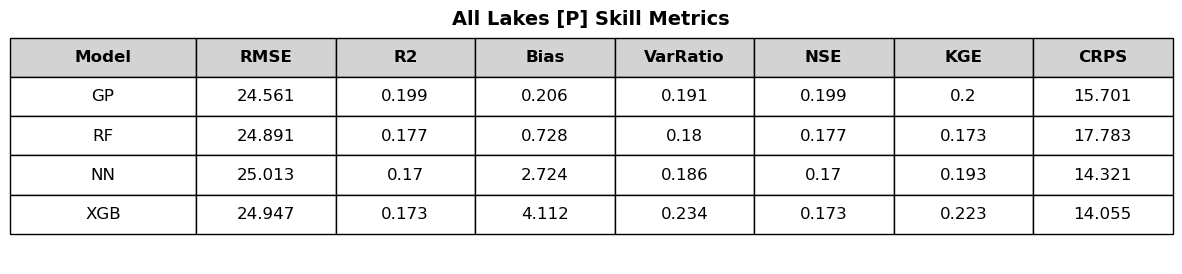

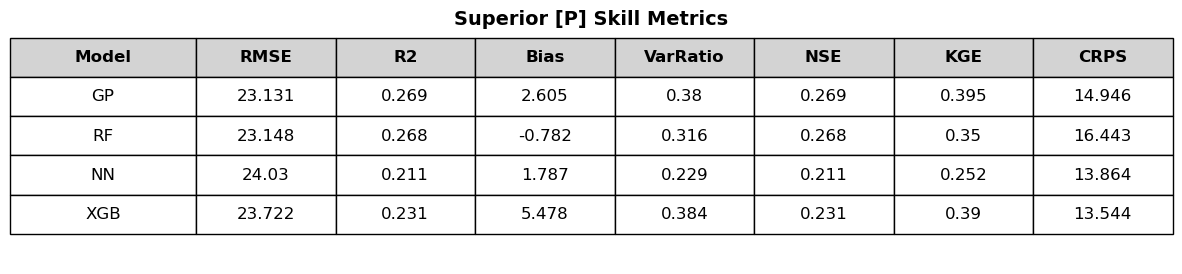

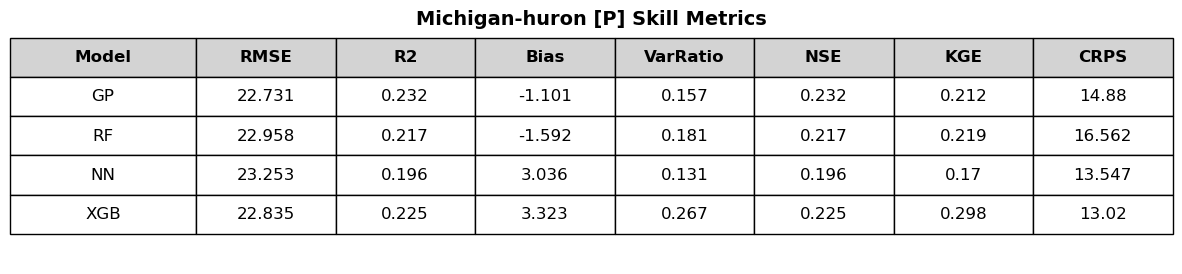

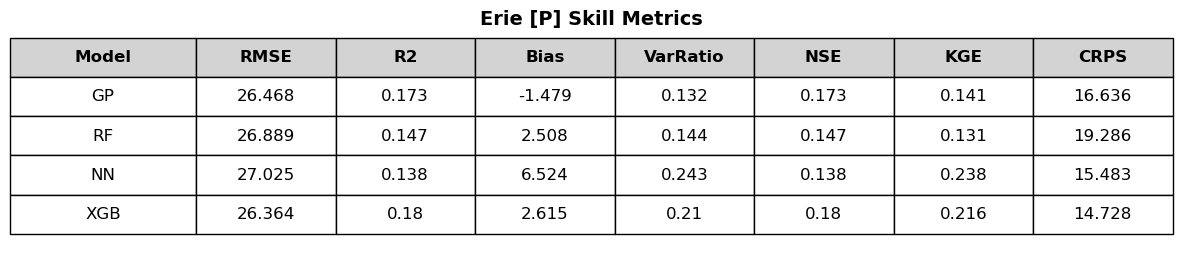

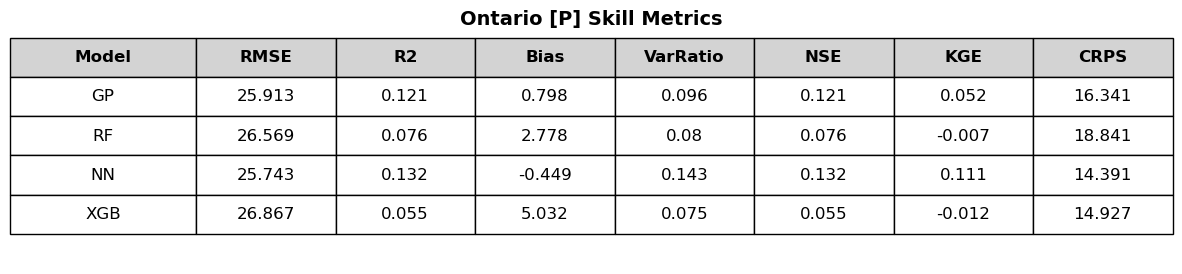

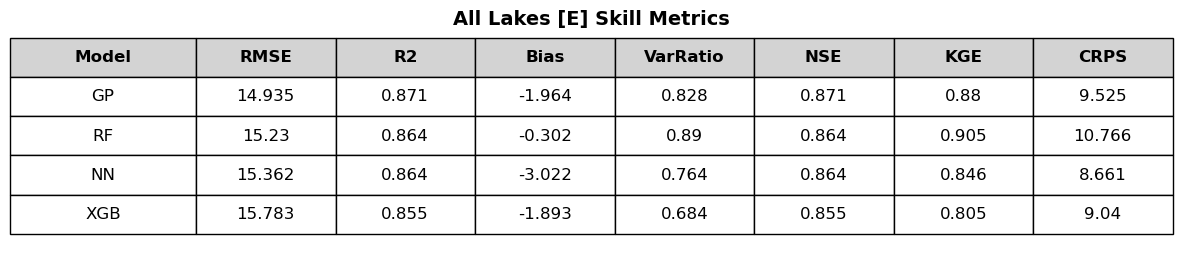

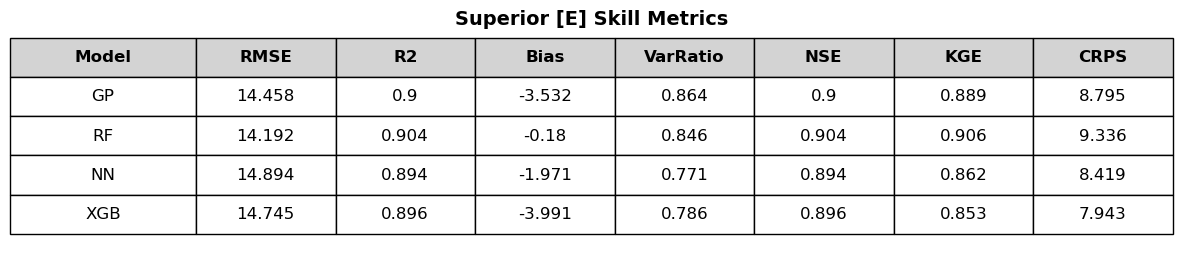

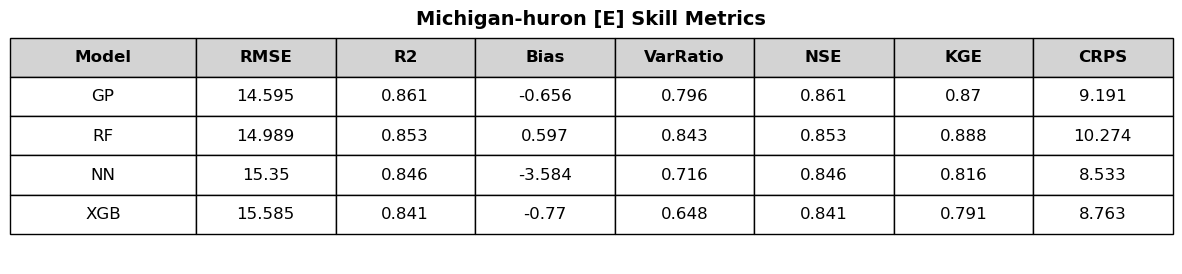

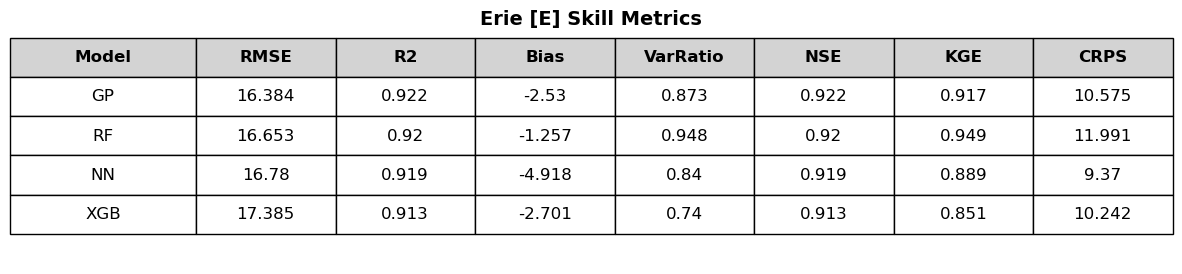

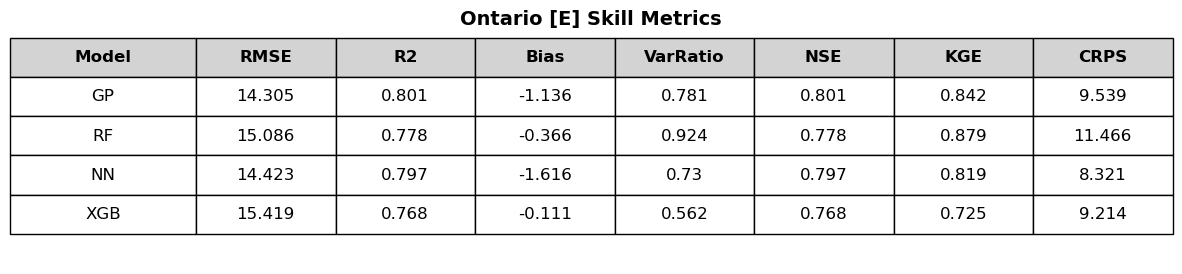

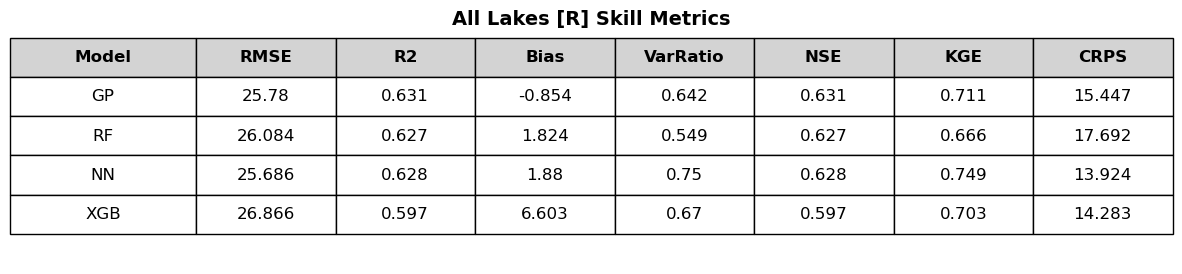

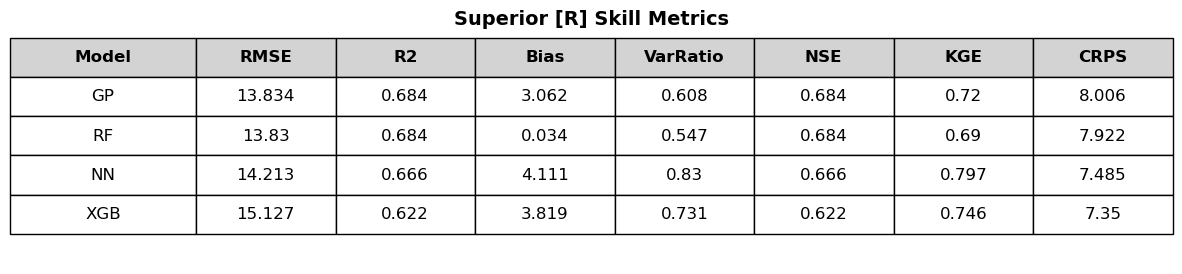

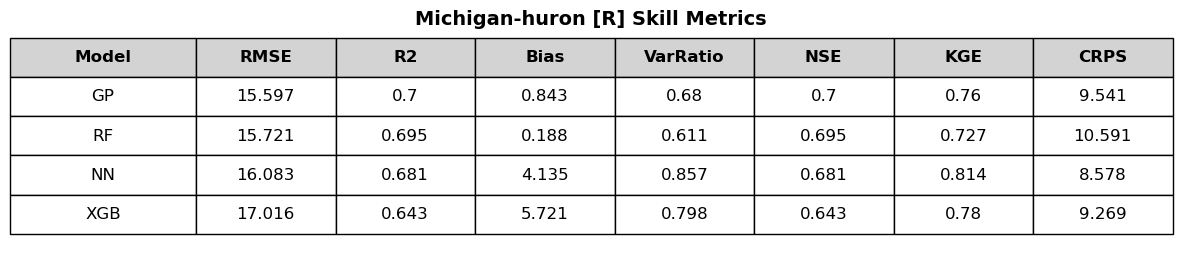

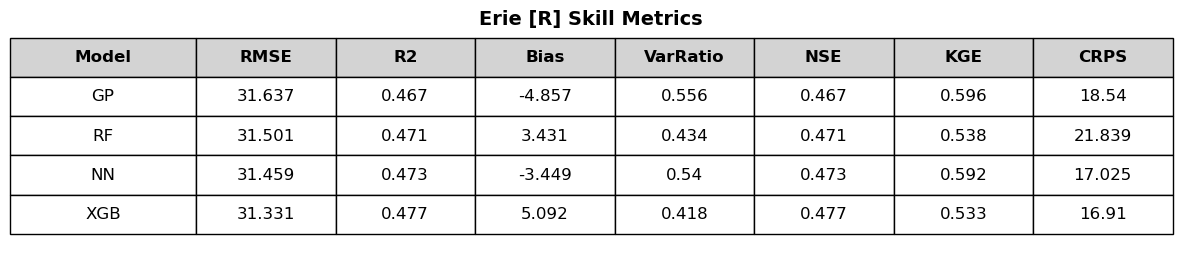

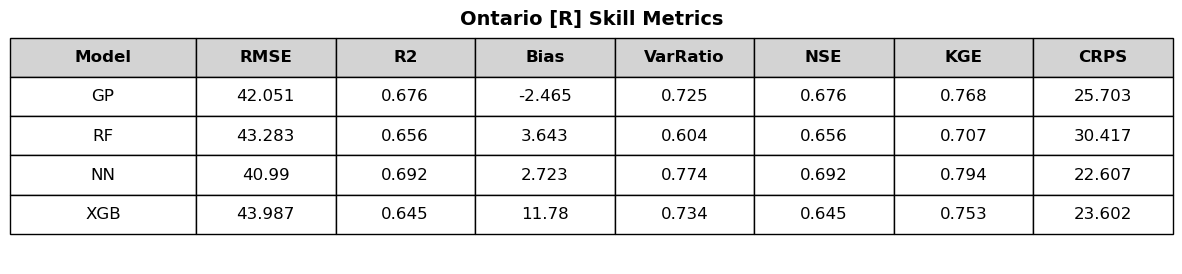

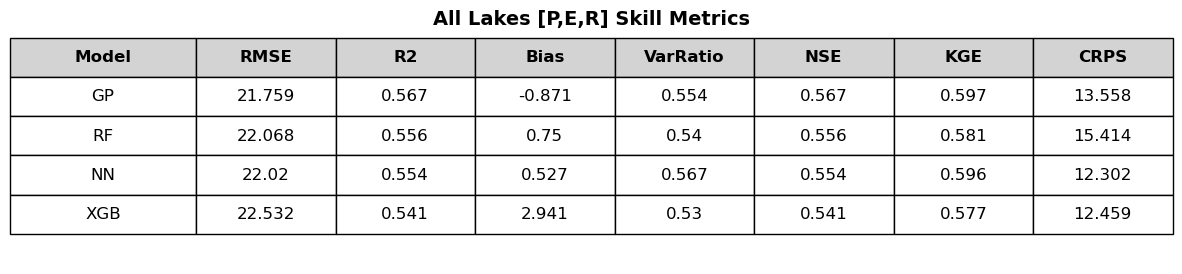

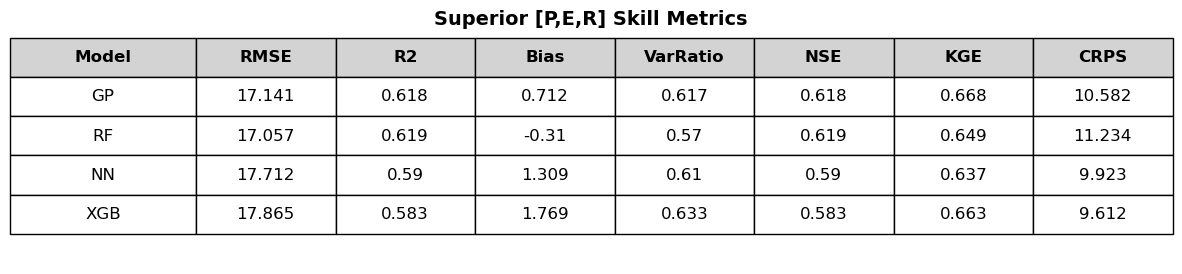

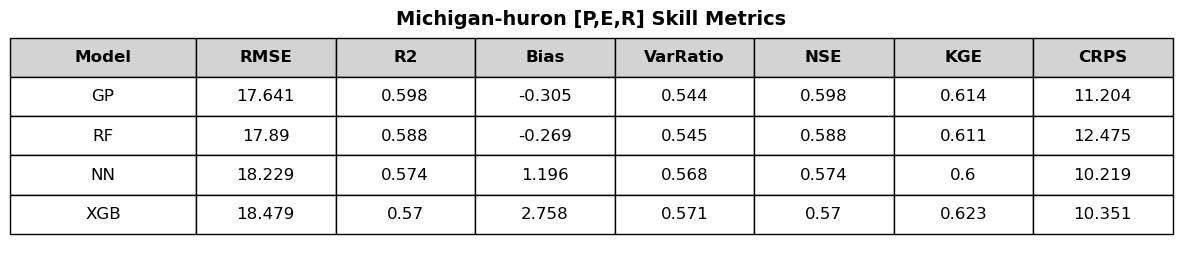

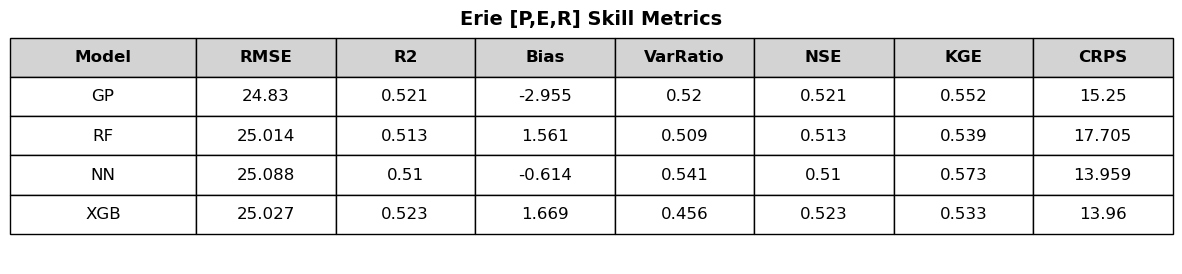

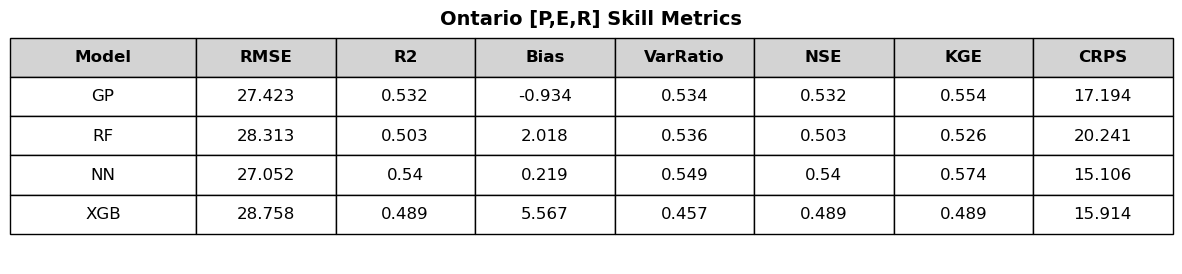

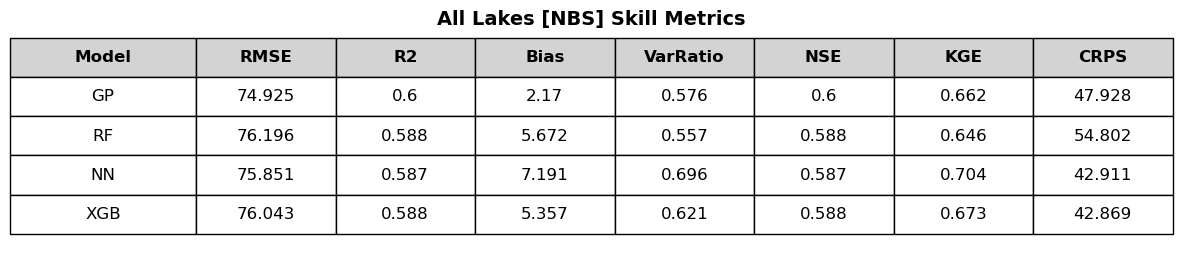

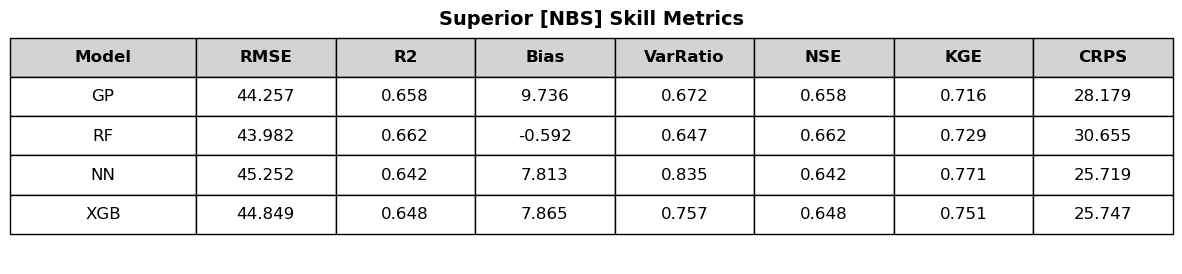

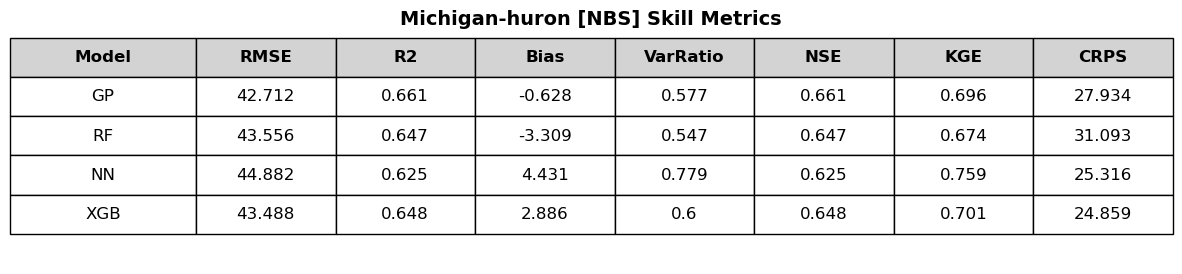

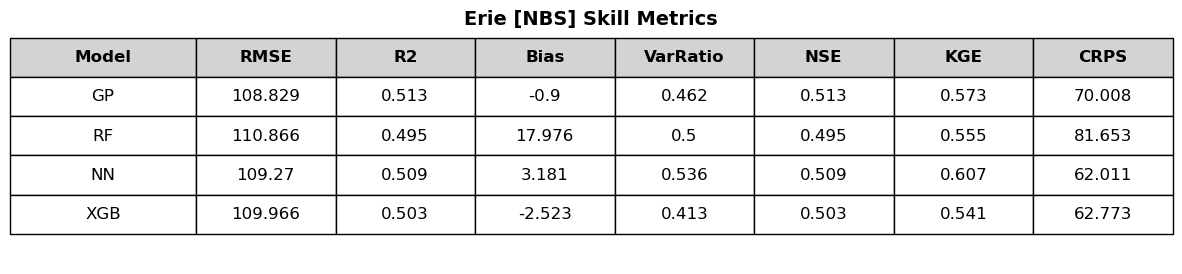

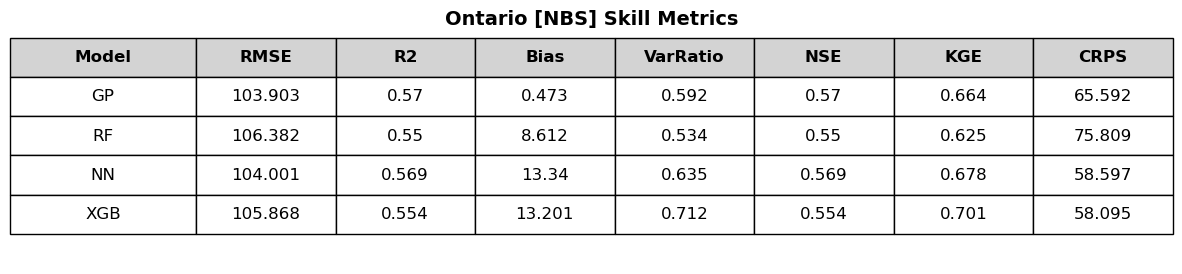

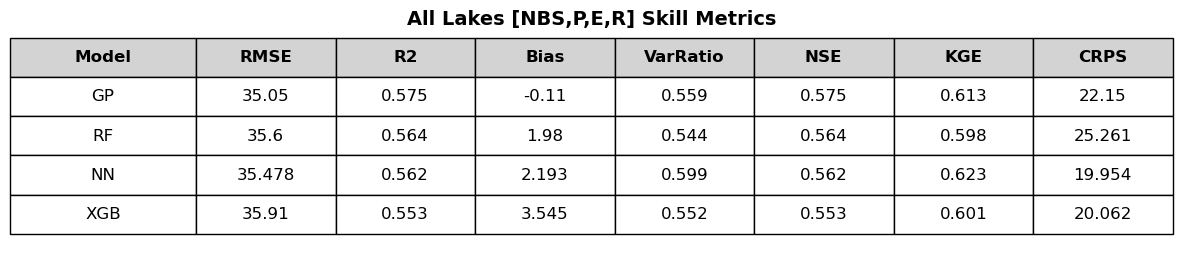

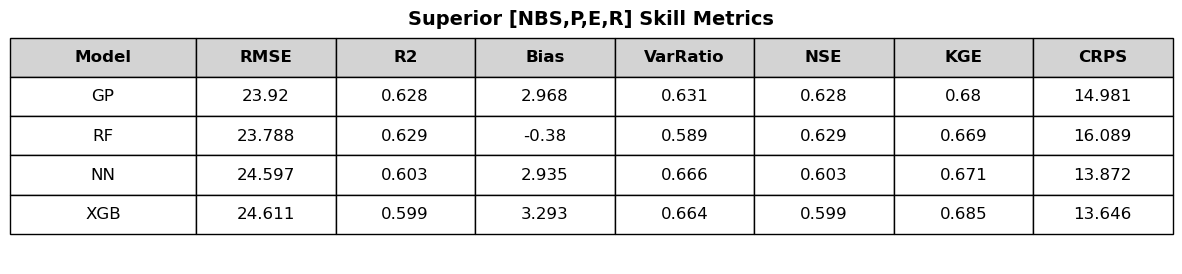

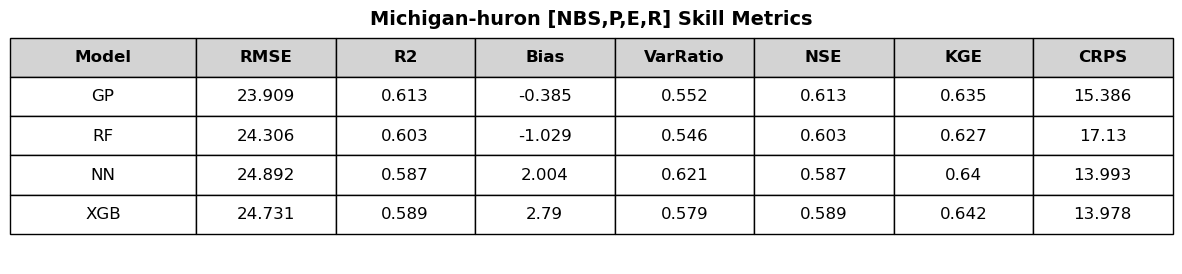

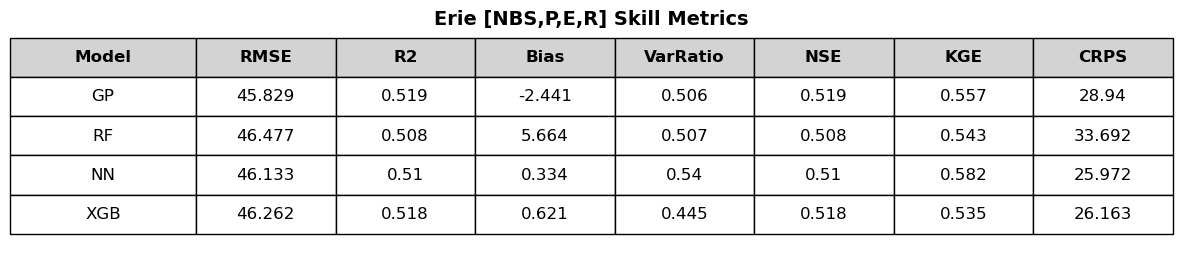

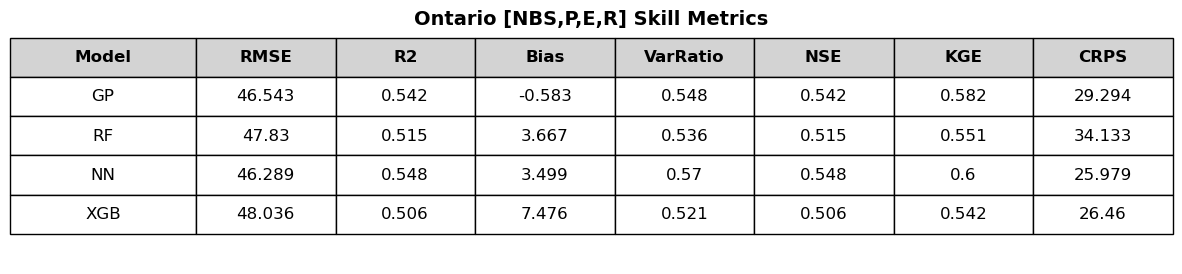

In [27]:
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
models = ['GP', 'RF', 'NN', 'XGB']

component_configs = [
    (['precipitation'], "[P] Skill Metrics"),
    (['evaporation'], "[E] Skill Metrics"),
    (['runoff'], "[R] Skill Metrics"),
    (['precipitation', 'evaporation', 'runoff'], "[P,E,R] Skill Metrics"),
    (['nbs'], "[NBS] Skill Metrics"),
    (['nbs', 'precipitation', 'evaporation', 'runoff'], "[NBS,P,E,R] Skill Metrics"),
]

selected_metrics = [
    'RMSE', 'R2',
    'Bias', 'VarRatio',
    'NSE', 'KGE', 
    'CRPS'
]

for components, title in component_configs:

    # =========================
    # ALL LAKES
    # =========================
    results = [
        compute_skill(
            df_combined,
            lakes=lakes,
            components=components,
            model=m,
            metrics=selected_metrics
        )
        for m in models
    ]

    df_all = pd.DataFrame(results)
    df_all = df_all[['Model'] + selected_metrics]

    plot_styled_table(df_all, title=f"All Lakes {title}")

    # =========================
    # PER LAKE
    # =========================
    for lake in lakes:

        results = [
            compute_skill(
                df_combined,
                lakes=[lake],
                components=components,
                model=m,
                metrics=selected_metrics
            )
            for m in models
        ]

        df_lake = pd.DataFrame(results)
        df_lake = df_lake[['Model'] + selected_metrics]

        plot_styled_table(df_lake, title=f"{lake.capitalize()} {title}")

NameError: name 'sns' is not defined

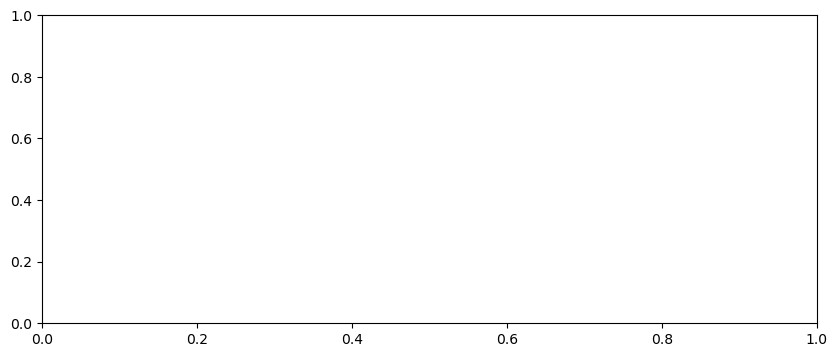

In [ ]:
import seaborn as sns

def prepare_skill_data(df, metrics):
    """
    Transform all metrics so higher = better before normalization.
    """
    df_plot = df.copy()
    df_plot = df_plot.set_index("Model")

    for m in metrics:
        if m in ["RMSE", "CRPS"]:
            # lower is better
            df_plot[m] = -df_plot[m]

        elif m == "Bias":
            # closest to zero is best
            df_plot[m] = -np.abs(df_plot[m])

        elif m == "VarRatio":
            # closest to 1 is best
            df_plot[m] = -np.abs(df_plot[m] - 1)

        # R2, NSE, KGE already higher = better

    return df_plot[metrics]


def normalize_columns(df):
    """
    Min-max normalize each metric column to [0, 1].
    """
    return df.apply(
        lambda x: (x - x.min()) / (x.max() - x.min())
        if x.max() != x.min()
        else 0.5,
        axis=0
    )


def plot_skill_heatmap(df_all, selected_metrics, title):
    df_transformed = prepare_skill_data(df_all, selected_metrics)
    df_normalized = normalize_columns(df_transformed)

    fig, ax = plt.subplots(figsize=(10, 4))

    sns.heatmap(
        df_normalized,
        cmap="viridis",
        vmin=0,
        vmax=1,
        annot=df_all.set_index("Model")[selected_metrics].round(2),
        fmt="",
        linewidths=0.5,
        linecolor="lightgray",
        cbar_kws={"label": "Normalized Skill (higher = better)"},
        ax=ax
    )

    ax.set_title(title, pad=12)
    ax.set_xlabel("Metric")
    ax.set_ylabel("Model")

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_skill_heatmap(
    df_all=df_all,
    selected_metrics=selected_metrics,
    title="All Lakes Skill Comparison (NBS,P,E,R)"
)

In [ ]:
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
models = ['GP', 'RF', 'NN', 'XGB']

component_configs = [
    (['precipitation'], "[P] Skill Metrics"),
    (['evaporation'], "[E] Skill Metrics"),
    (['runoff'], "[R] Skill Metrics"),
    (['precipitation', 'evaporation', 'runoff'], "[P,E,R] Skill Metrics"),
    (['nbs'], "[NBS] Skill Metrics"),
    (['nbs', 'precipitation', 'evaporation', 'runoff'], "[NBS,P,E,R] Skill Metrics"),
]

selected_metrics = [
    'RMSE', 'RMSE_ext',
    'R2', 'R2_ext',
    'Bias', 'Bias_ext'
]

 

In [ ]:
df_tidy['cfs_run'] = pd.to_datetime(df_tidy['cfs_run'])
df_tidy['forecast_month'] = pd.to_datetime(df_tidy['forecast_month'])

# For each forecast run, keep only the first 6 months
df_first6 = (
    df_combined.sort_values(['cfs_run', 'forecast_month'])
      .groupby(['cfs_run', 'model'])
      .head(6)  # keep first 6 rows per run/model
      .reset_index(drop=True)
)

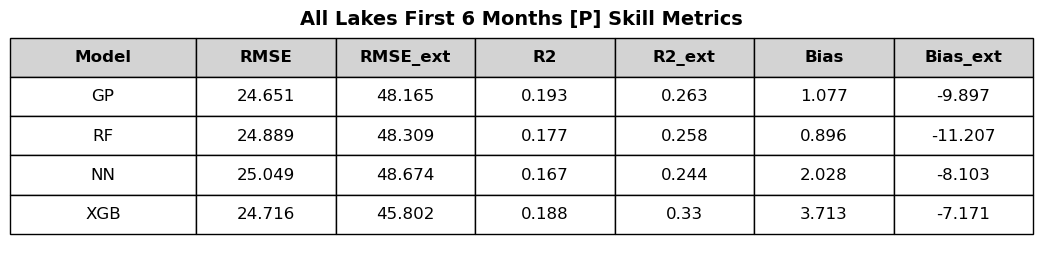

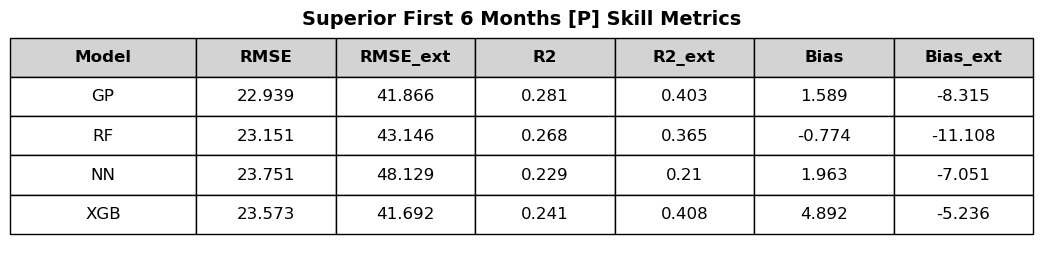

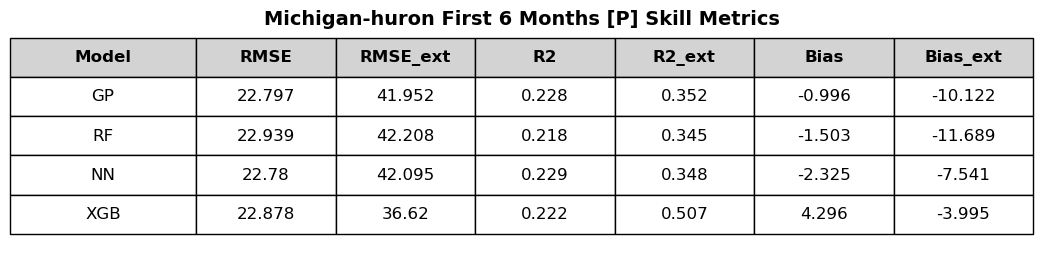

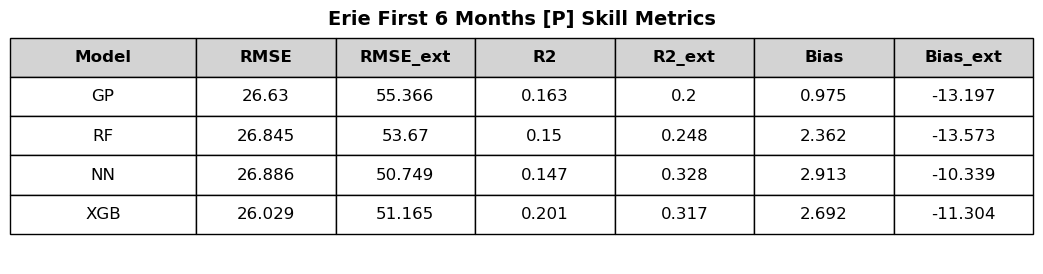

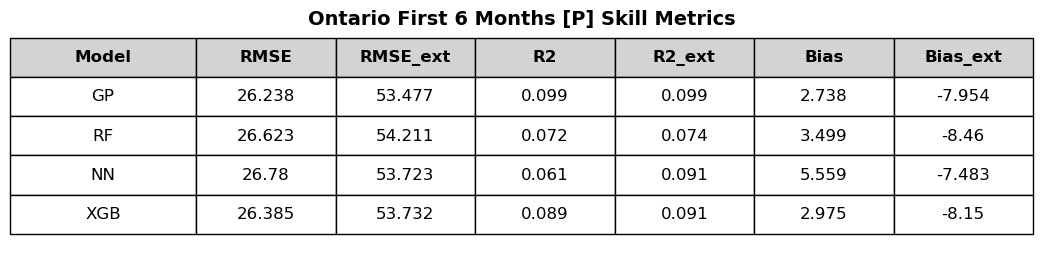

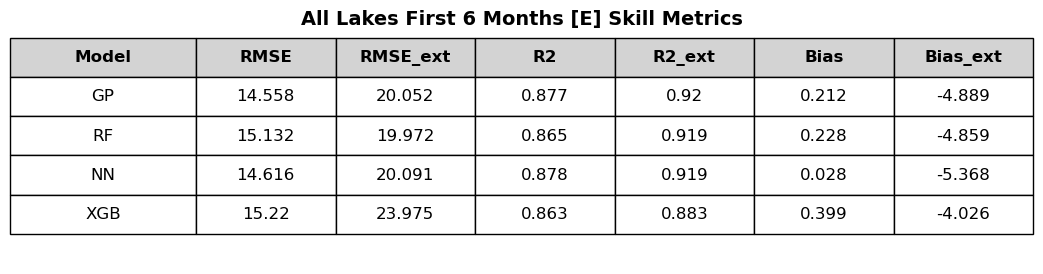

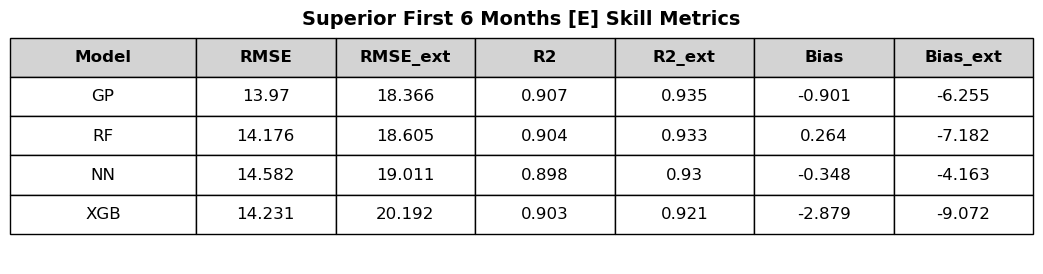

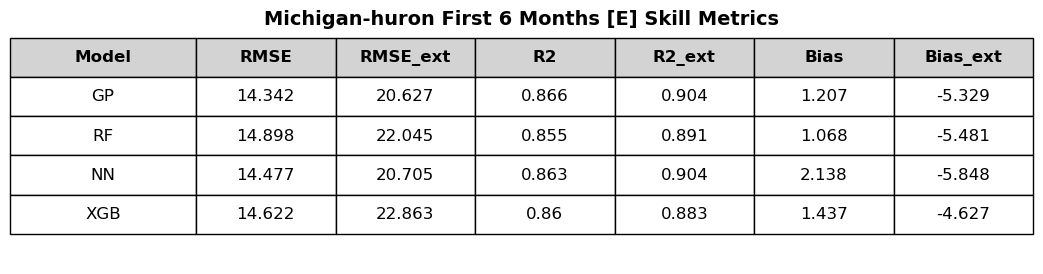

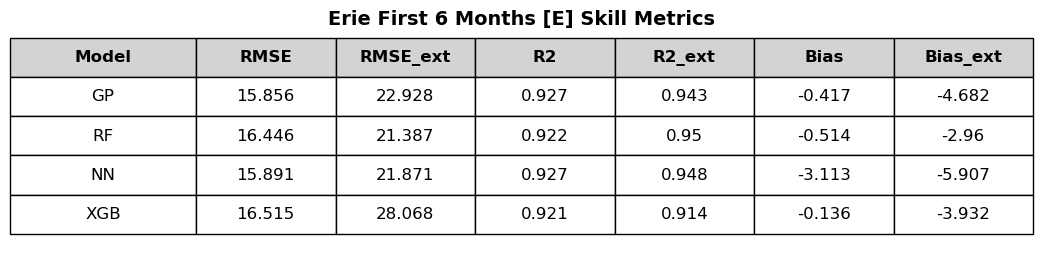

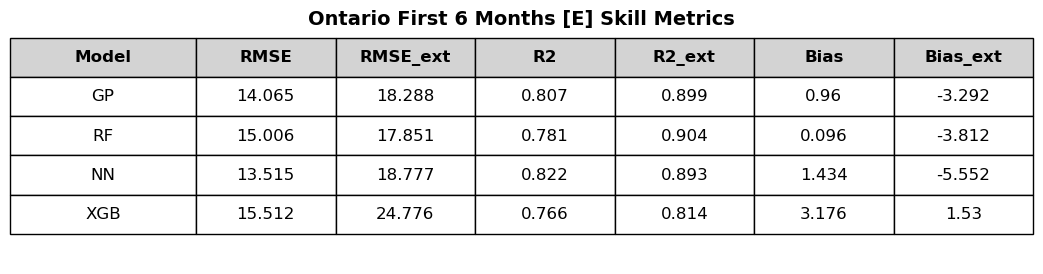

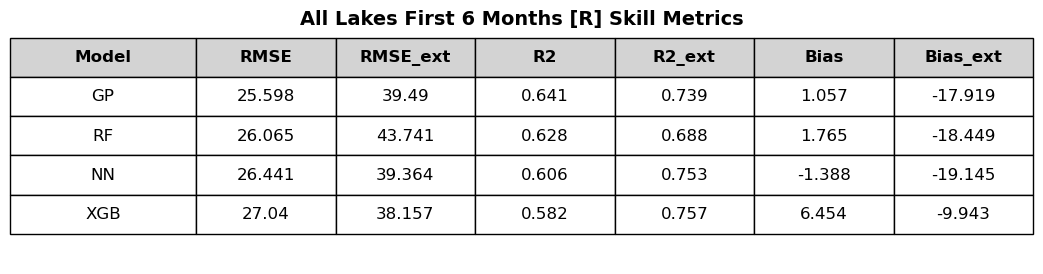

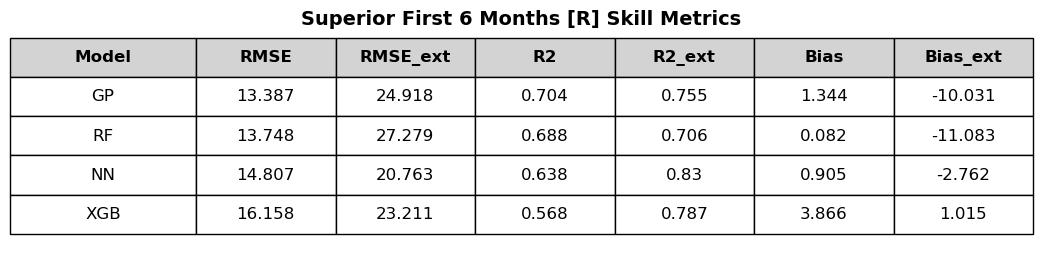

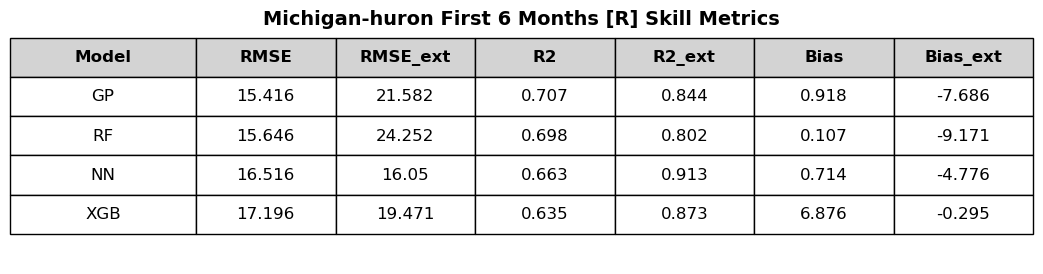

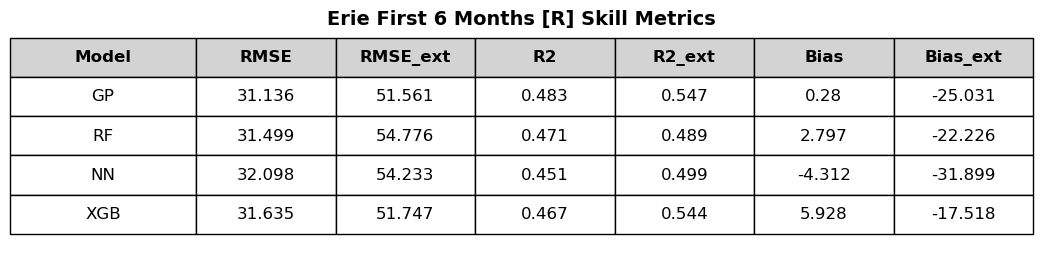

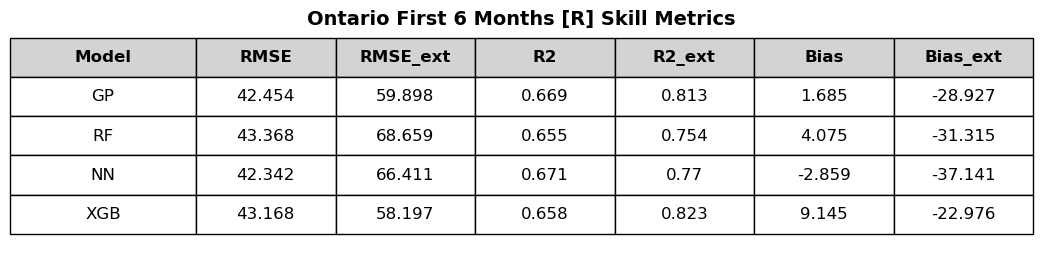

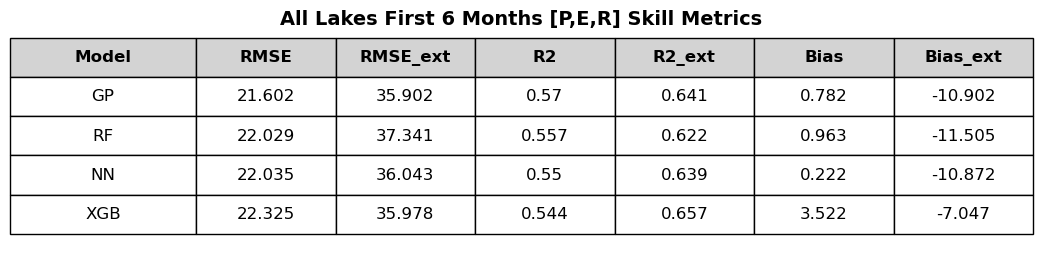

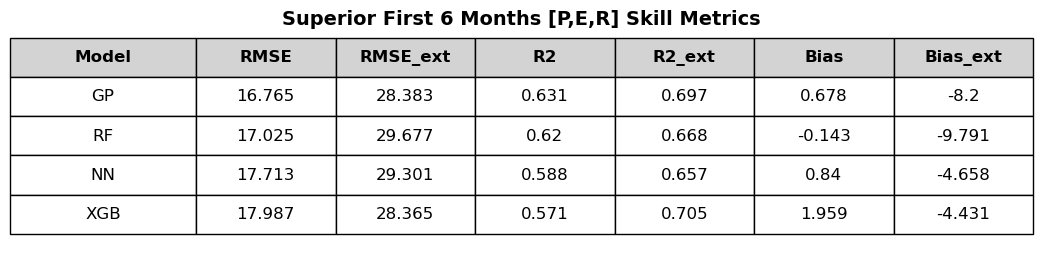

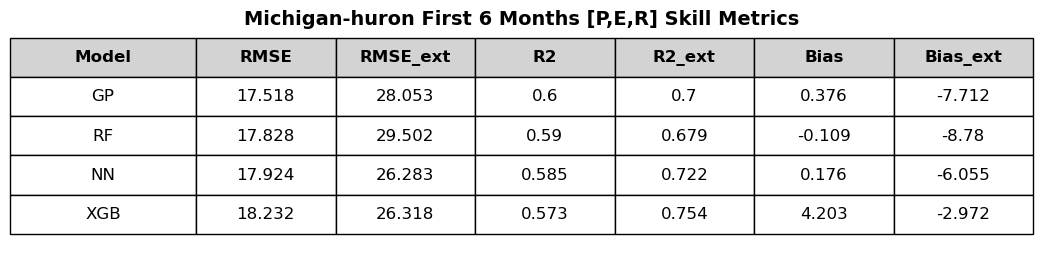

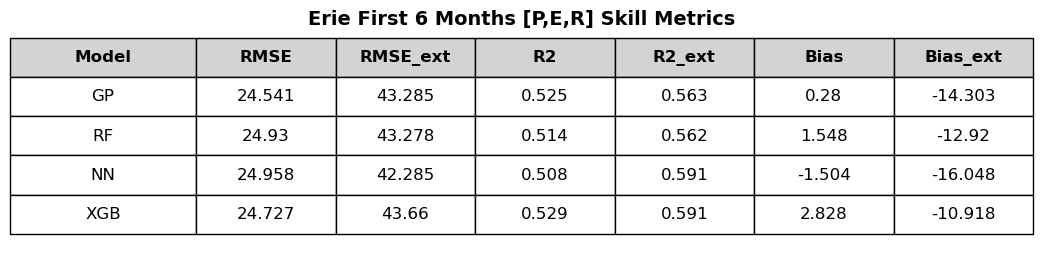

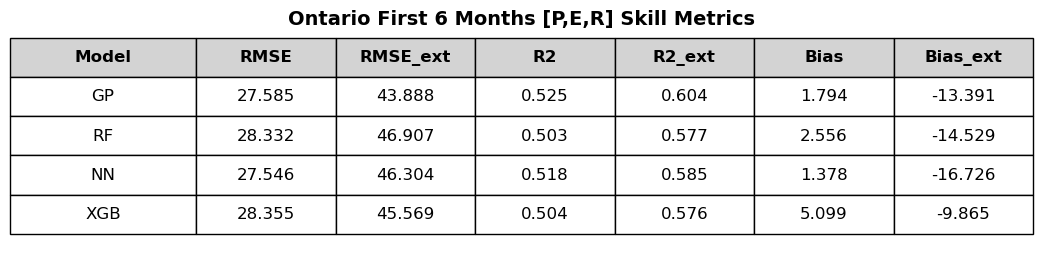

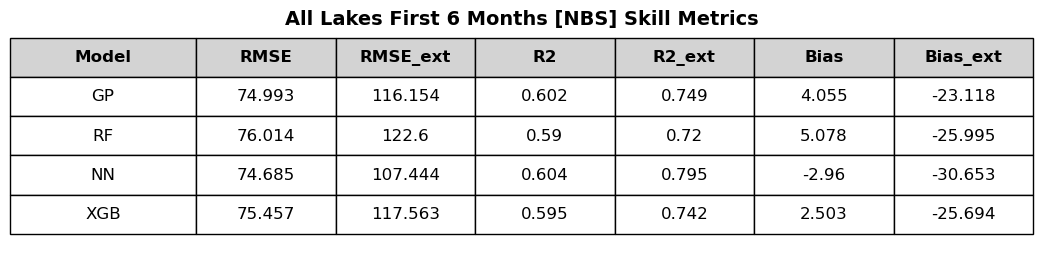

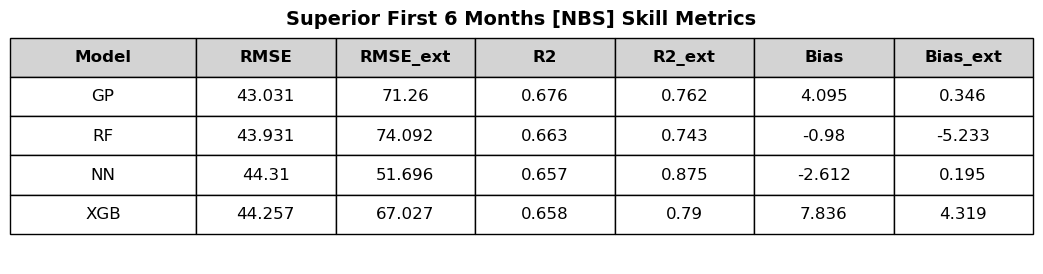

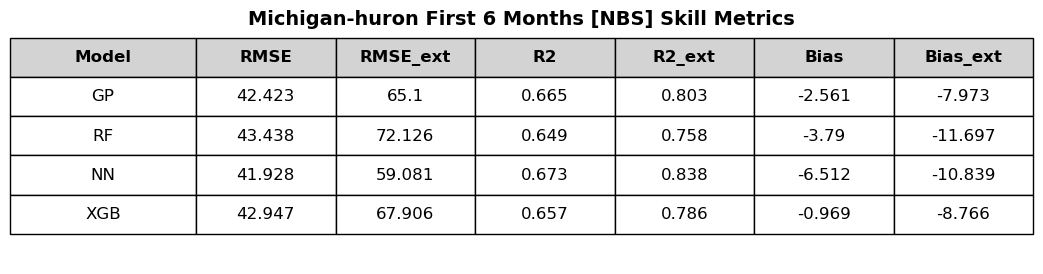

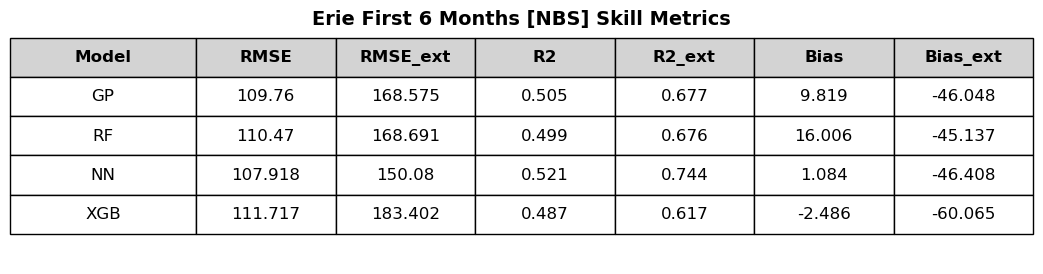

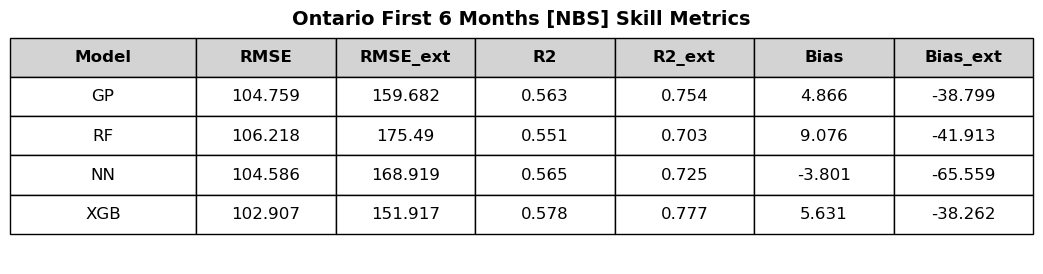

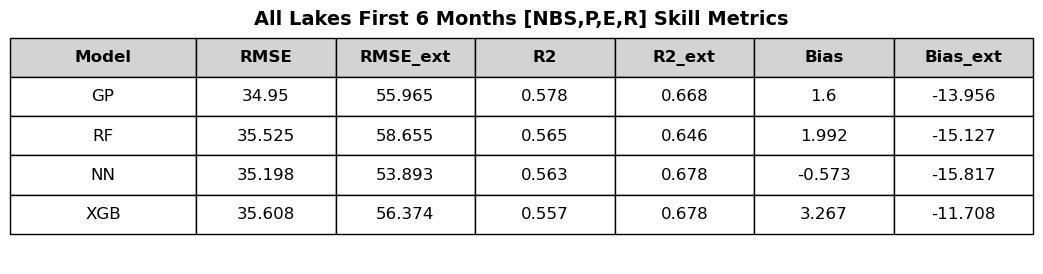

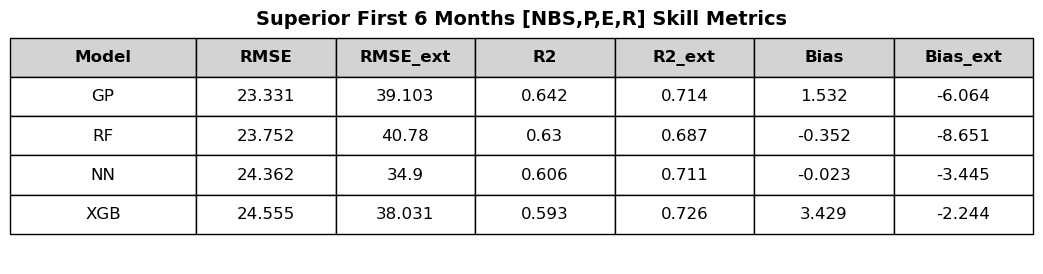

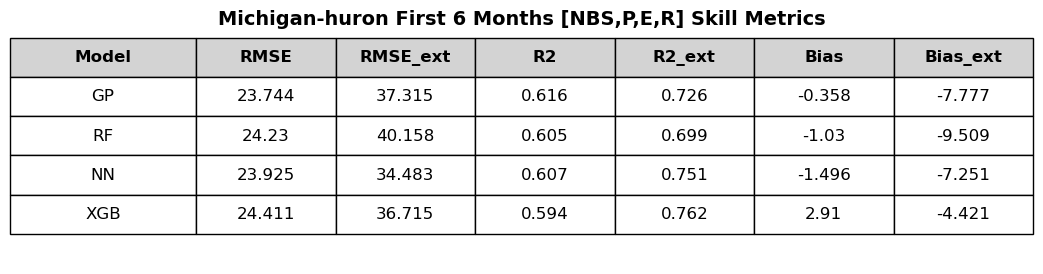

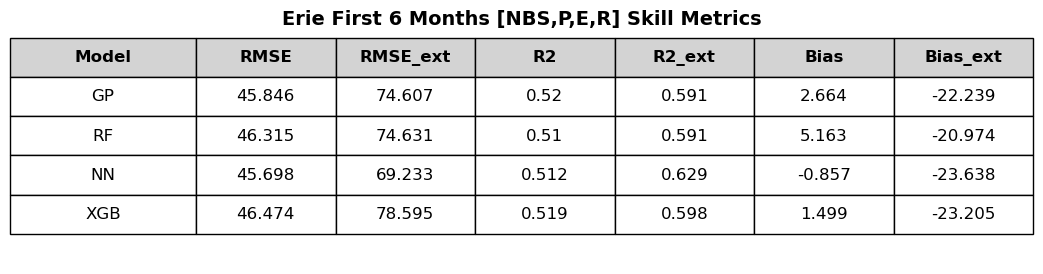

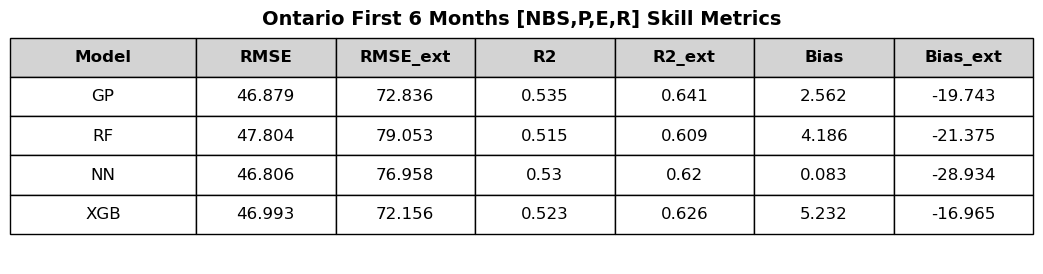

In [ ]:
# lakes and models stay constant
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
models = ['GP', 'RF', 'NN', 'XGB']

# component configurations and plot titles
component_configs = [
    (['precipitation'], "First 6 Months [P] Skill Metrics"),
    (['evaporation'], "First 6 Months [E] Skill Metrics"),
    (['runoff'], "First 6 Months [R] Skill Metrics"),
    (['precipitation', 'evaporation', 'runoff'], "First 6 Months [P,E,R] Skill Metrics"),
    (['nbs'], "First 6 Months [NBS] Skill Metrics"),
    (['nbs', 'precipitation', 'evaporation', 'runoff'], "First 6 Months [NBS,P,E,R] Skill Metrics"),
]

for components, title in component_configs:

    # =========================
    # ALL LAKES
    # =========================
    results = [
        compute_skill(
            df_first6,
            lakes=lakes,
            components=components,
            model=m,
            metrics=selected_metrics
        )
        for m in models
    ]

    df_all = pd.DataFrame(results)
    df_all = df_all[['Model'] + selected_metrics]

    plot_styled_table(df_all, title=f"All Lakes {title}")

    # =========================
    # PER LAKE
    # =========================
    for lake in lakes:

        results = [
            compute_skill(
                df_first6,
                lakes=[lake],
                components=components,
                model=m,
                metrics=selected_metrics
            )
            for m in models
        ]

        df_lake = pd.DataFrame(results)
        df_lake = df_lake[['Model'] + selected_metrics]

        plot_styled_table(df_lake, title=f"{lake.capitalize()} {title}")

In [ ]:
df = data.copy()

df["date"] = pd.to_datetime(df["year"].astype(str) + "-" + df["month"].astype(str) + "-01")

# 2. Filter only surface_type == lake
df = df[df["surface_type"] == "lake"]

# 3. Create "variable" column
df["variable"] = df["lake"] + "_" + df["component"]

# 4. Pivot to wide format
pivot_df = df.pivot_table(
    index=["date", "cfs_run"],  # keep these as identifiers
    columns="variable",
    values="value [mm]",
    aggfunc="mean"  # in case of duplicates
).reset_index()

# Optional: flatten column names after pivot
pivot_df.columns.name = None  # remove pivot column grouping name

df_cfs_mean =(pivot_df.groupby(["date"]).mean(numeric_only=True))
df_cfs = df_cfs_mean.reset_index()

In [ ]:
df_mean = df_combined.groupby(['forecast_month','model']).mean()
df_mean = df_mean.reset_index()

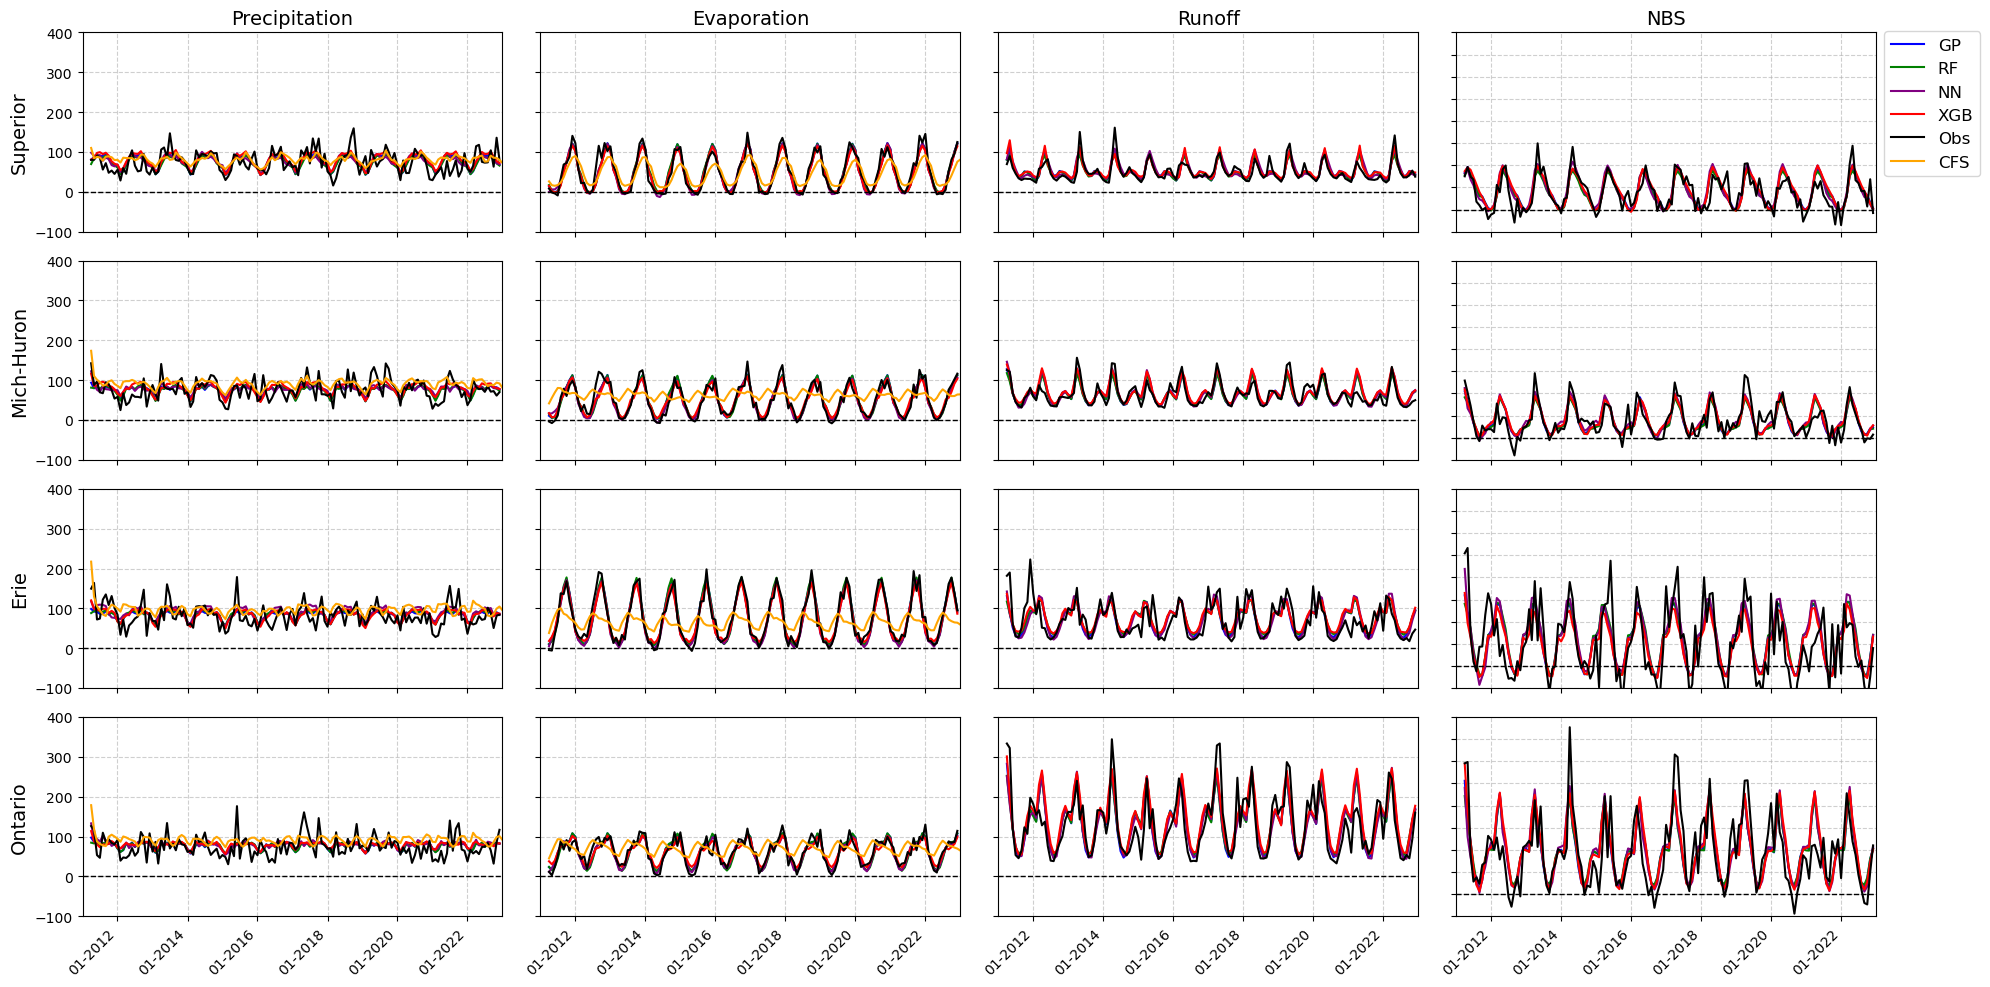

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd# Define model colors
model_colors = {'GP': 'blue', 'RF': 'green', 'XGB': 'red', 'NN': 'purple'}

# Define lake names and components
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
components = ['precipitation', 'evaporation', 'runoff', 'nbs']
titles = ['Precipitation', 'Evaporation', 'Runoff', 'NBS']
ylabels = ['Superior', 'Mich-Huron', 'Erie', 'Ontario']

# Create subplot grid
fig, axs = plt.subplots(4, 4, figsize=(20, 10))
axs = axs.reshape(4, 4)

# Loop through all combinations of lake and component
for row, lake in enumerate(lakes):
    for col, comp in enumerate(components):
        ax = axs[row, col]
        column = f'{lake}_{comp}'
        obs_column = f'{column}_obs'

        for model_name in models_list:
            model_df = df_mean[df_mean['model'] == model_name].copy()
            
            # Plot model prediction
            ax.plot(model_df['date'], model_df[column],
                    color=model_colors[model_name], label=model_name)

        # Plot observations
        ax.plot(model_df['date'], model_df[obs_column],
                color='black', linewidth=1.5, label='Obs')

        # Only plot CFS for precipitation + evaporation
        if comp in ['precipitation', 'evaporation']:
            ax.plot(df_cfs['date'], df_cfs[column],
                    color='orange', linewidth=1.5, label='CFS')
        
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.set_yticks(np.arange(-1000, 1000, 100))

        # Set titles and labels
        if row == 0:
            ax.set_title(titles[col], fontsize=14)
        if row == 3:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
            ax.tick_params(axis='x', rotation=45)
            for label in ax.get_xticklabels():
                label.set_horizontalalignment('right')
        else:
            ax.set_xticklabels([])

        if col == 0:
            ax.set_ylabel(ylabels[row], fontsize=14)
        else:
            ax.set_yticklabels([])
        if col == 3:
            ax.set_ylim(-100, 800)
        else:
            ax.set_ylim(-100, 400)

# Get handles and labels from (0,0)
handles, labels = axs[0, 0].get_legend_handles_labels()

# Place legend in (0,3) using those colors
axs[0, 3].legend(
    handles,
    labels,
    loc='lower left',
    bbox_to_anchor=(1, 0.236),
    fontsize=12
)

start_date = pd.to_datetime('2011-01-01')
end_date = pd.to_datetime('2023-01-01')

for ax_row in axs:
    for ax in ax_row:
        ax.set_xlim(start_date, end_date)

# Save and show plot
plt.tight_layout()
plt.savefig('CNBS_forecasts.png', dpi=300)
plt.show()

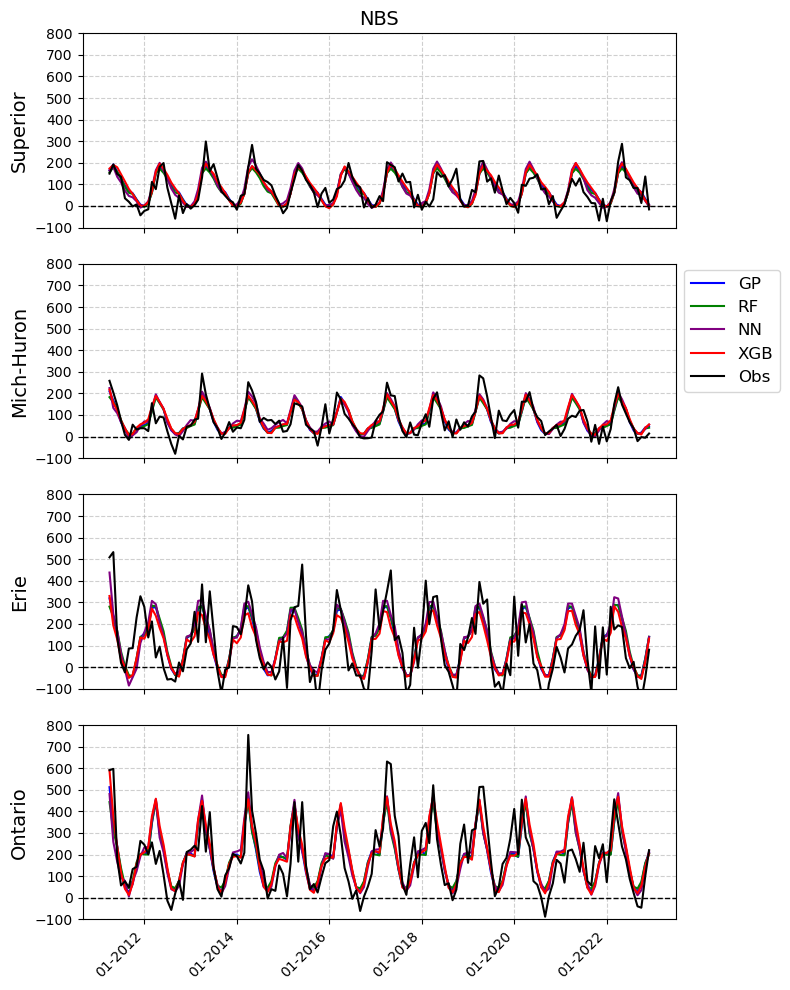

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

# Define model colors
model_colors = {'GP': 'blue', 'RF': 'green', 'XGB': 'red', 'NN': 'purple'}

# Define lake names and components
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
components = ['nbs']
titles = ['NBS']
ylabels = ['Superior', 'Mich-Huron', 'Erie', 'Ontario']

# Create subplot grid
fig, axs = plt.subplots(4, 1, figsize=(8, 10))
axs = axs.reshape(4, 1)

# Loop through all combinations of lake and component
for row, lake in enumerate(lakes):
    for col, comp in enumerate(components):
        ax = axs[row, col]
        column = f'{lake}_{comp}'
        obs_column = f'{column}_obs'

        for model_name in models_list:
            model_df = df_mean[df_mean['model'] == model_name].copy()
            
            # Plot model prediction
            ax.plot(model_df['date'], model_df[column],
                    color=model_colors[model_name], label=model_name)

        # Plot observations
        ax.plot(model_df['date'], model_df[obs_column],
                color='black', linewidth=1.5, label='Obs')

        # Only plot CFS for precipitation + evaporation
        if comp in ['precipitation', 'evaporation']:
            ax.plot(df_cfs['date'], df_cfs[column],
                    color='orange', linewidth=1.5, label='CFS')
        
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.set_yticks(np.arange(-1000, 1000, 100))

        # Set titles and labels
        if row == 0:
            ax.set_title(titles[col], fontsize=14)
        if row == 3:
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%Y'))
            ax.tick_params(axis='x', rotation=45)
            for label in ax.get_xticklabels():
                label.set_horizontalalignment('right')
        else:
            ax.set_xticklabels([])

        if col == 0:
            ax.set_ylabel(ylabels[row], fontsize=14)
        else:
            ax.set_yticklabels([])
        if col == 3:
            ax.set_ylim(-100, 800)
        else:
            ax.set_ylim(-100, 800)

# Add legend once
axs[1, 0].legend(loc='lower left', bbox_to_anchor=(1, 0.3), fontsize=12)

start_date = pd.to_datetime('2014-01-01')
end_date = pd.to_datetime('2015-01-01')

#for ax_row in axs:
#    for ax in ax_row:
#        ax.set_xlim(start_date, end_date)

# Save and show plot
plt.tight_layout()
plt.savefig('NBS_forecasts.png', dpi=300)
plt.show()

Calculate skill metrics based on month and season

In [ ]:
import pandas as pd

# ensure datetime
df = df_combined.copy()
df['forecast_month_dt'] = pd.to_datetime(df['forecast_month'])

# numeric month (1–12)
df['month'] = df['forecast_month_dt'].dt.month

# month name (Jan, Feb, etc.) – optional but nice for plots
df['month_name'] = df['forecast_month_dt'].dt.strftime('%b')


In [ ]:
def month_to_season(month):
    if month in [12, 1, 2]:
        return 'DJF'
    elif month in [3, 4, 5]:
        return 'MAM'
    elif month in [6, 7, 8]:
        return 'JJA'
    else:
        return 'SON'

df['season'] = df['month'].apply(month_to_season)


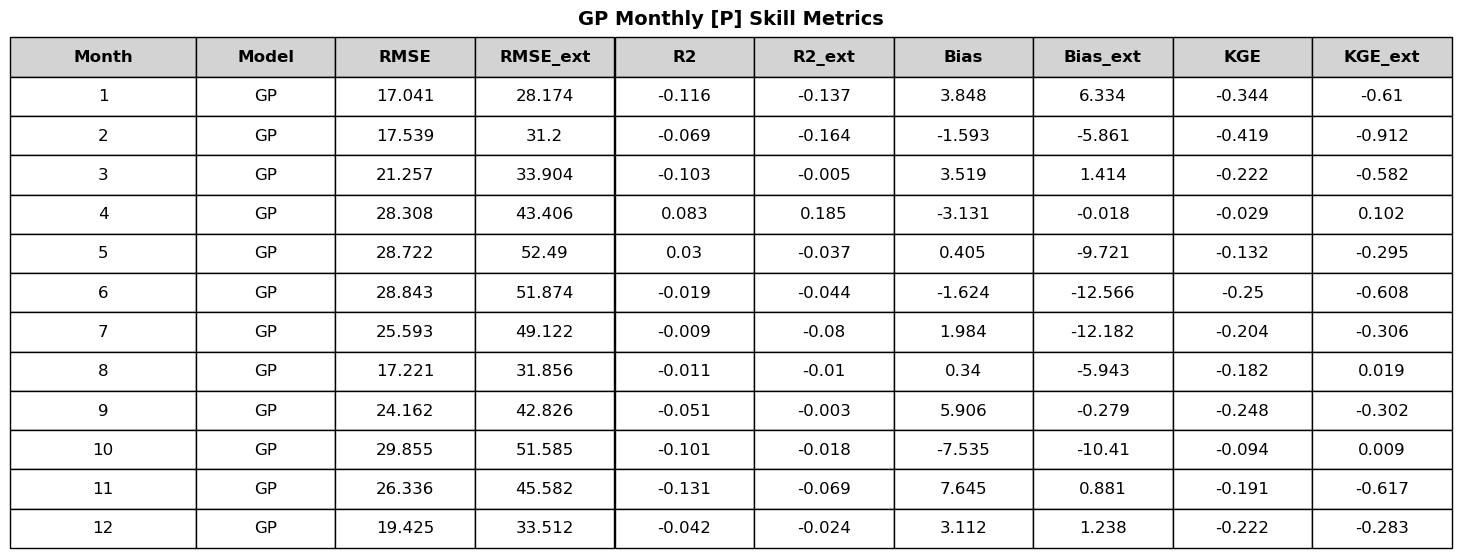

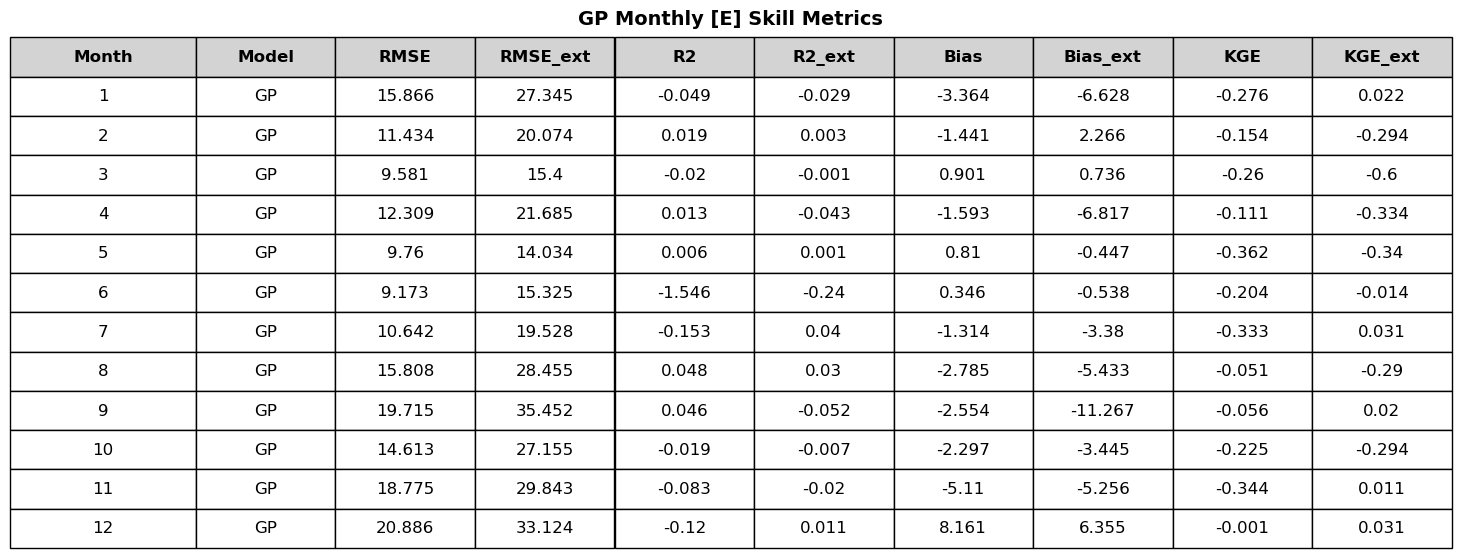

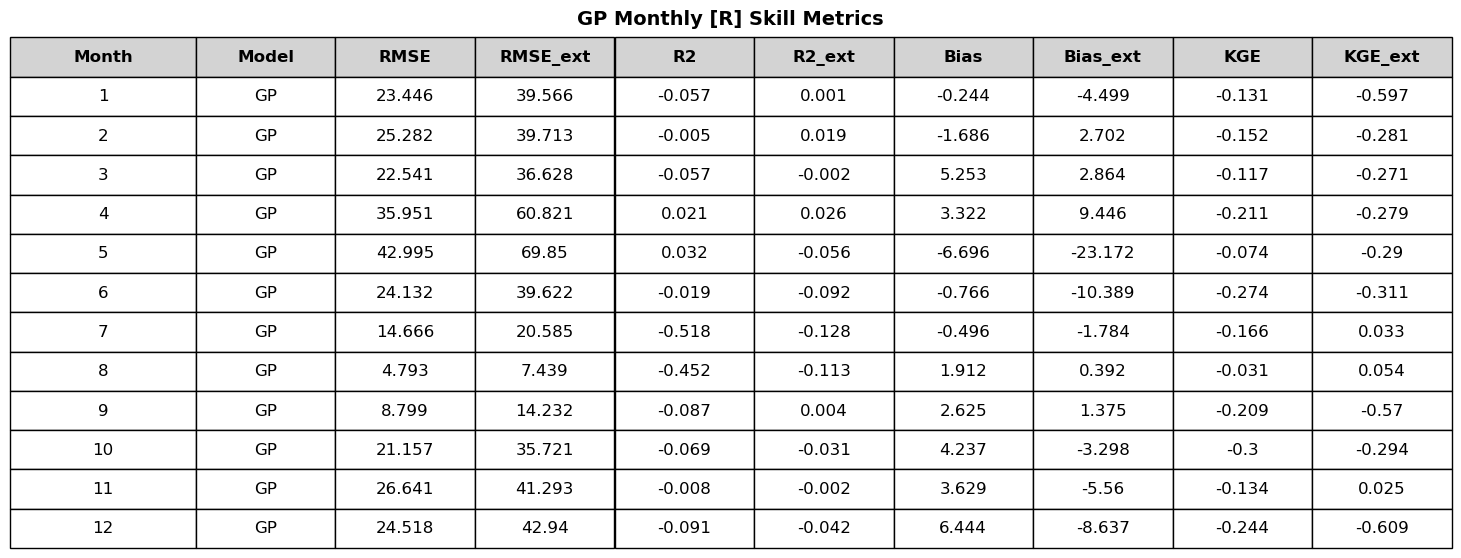

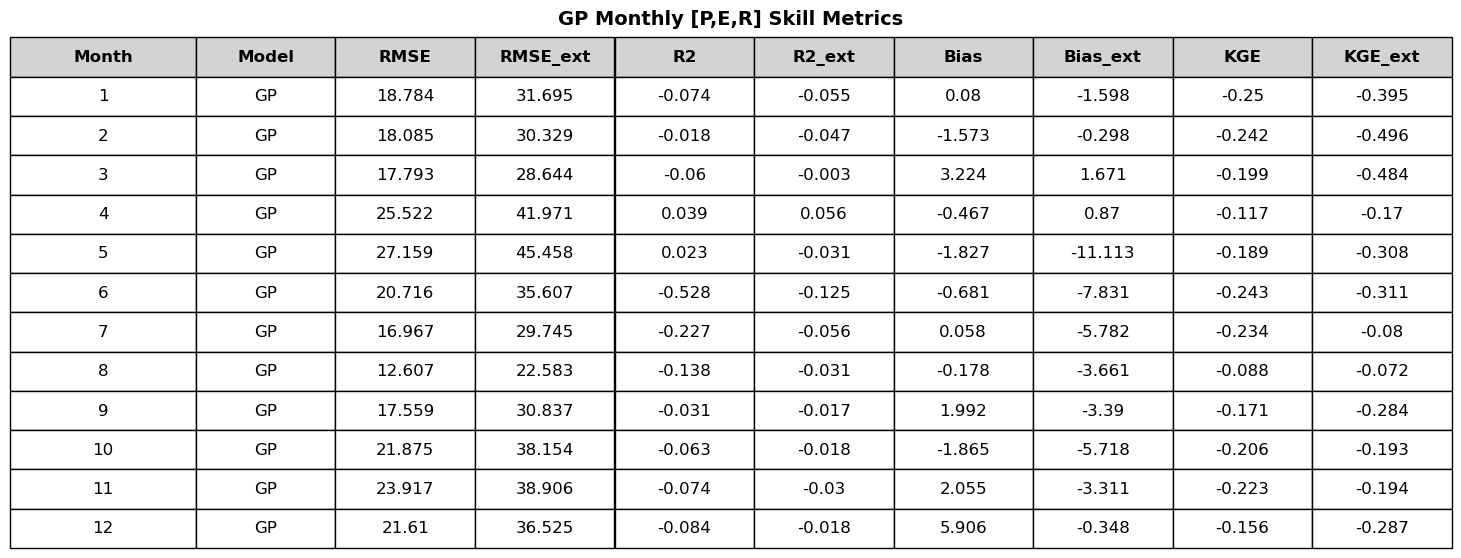

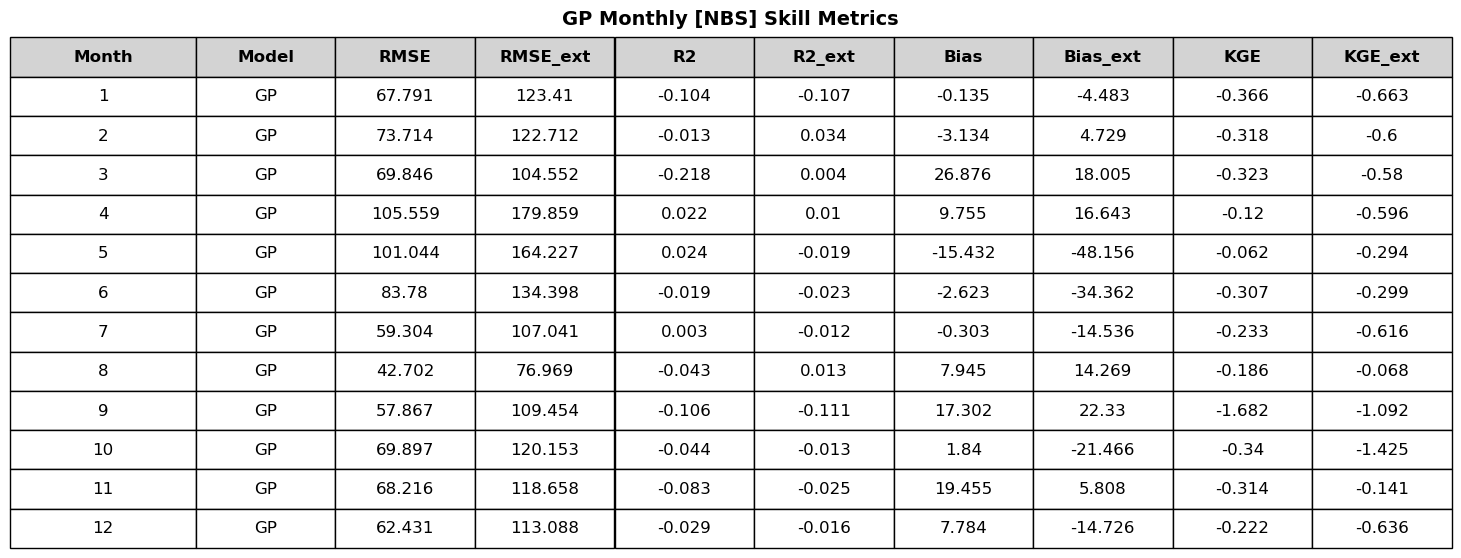

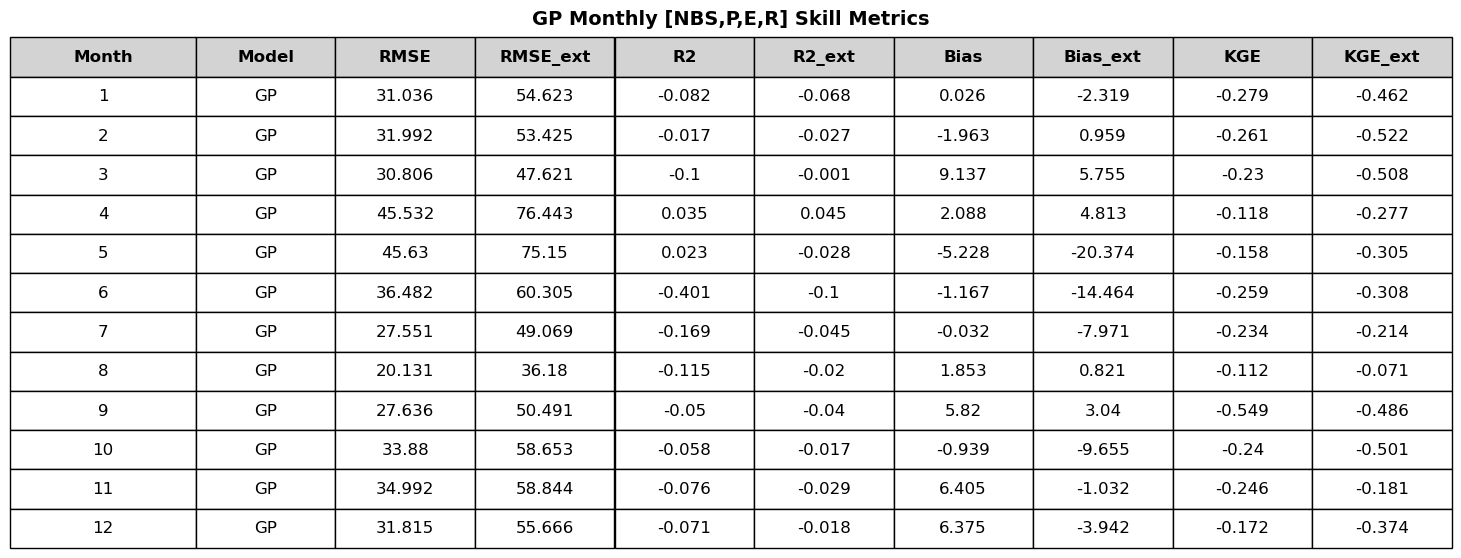

In [ ]:
# lakes and models stay constant
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
models = ['GP']

# component configurations and plot titles
component_configs = [
    (['precipitation'], "GP Monthly [P] Skill Metrics"),
    (['evaporation'], "GP Monthly [E] Skill Metrics"),
    (['runoff'], "GP Monthly [R] Skill Metrics"),
    (['precipitation', 'evaporation', 'runoff'], "GP Monthly [P,E,R] Skill Metrics"),
    (['nbs'], "GP Monthly [NBS] Skill Metrics"),
    (['nbs', 'precipitation', 'evaporation', 'runoff'], "GP Monthly [NBS,P,E,R] Skill Metrics"),
]

selected_metrics = [
    'RMSE', 'RMSE_ext',
    'R2', 'R2_ext',
    'Bias', 'Bias_ext',
    'KGE', 'KGE_ext'
]

for components, title in component_configs:

    monthly_results = []

    for month in range(1, 13):
        df_month = df[df['month'] == month]

        if df_month.empty:
            continue

        for model in models:

            skill = compute_skill(
                df_month,
                lakes=lakes,
                components=components,
                model=model,
                metrics=selected_metrics,
                date_col='forecast_month_dt'
            )

            skill['Month'] = month
            monthly_results.append(skill)

    monthly_skill_df = pd.DataFrame(monthly_results)

    if monthly_skill_df.empty:
        continue

    # enforce column order
    monthly_skill_df = monthly_skill_df[['Month', 'Model'] + selected_metrics]

    plot_styled_table(
        monthly_skill_df,
        title=title
    )

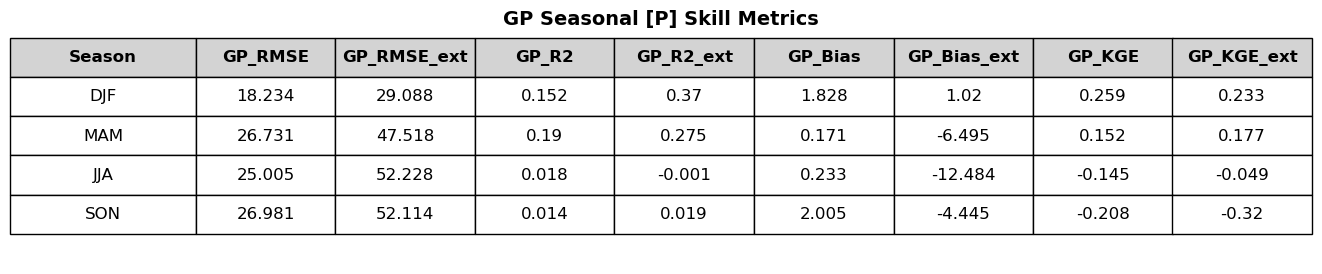

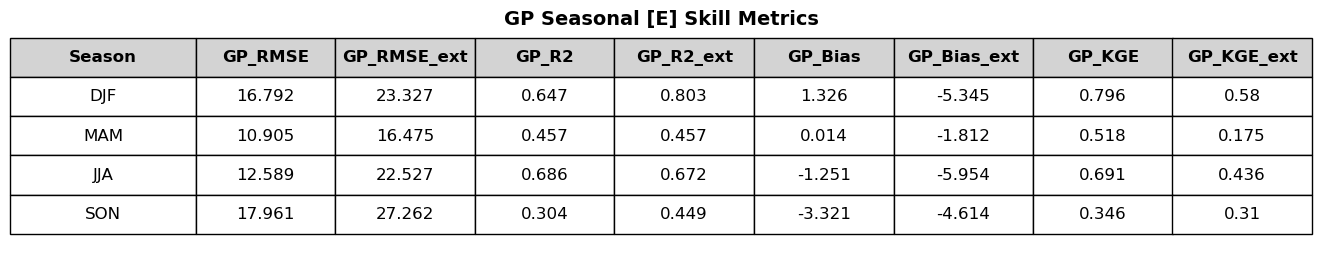

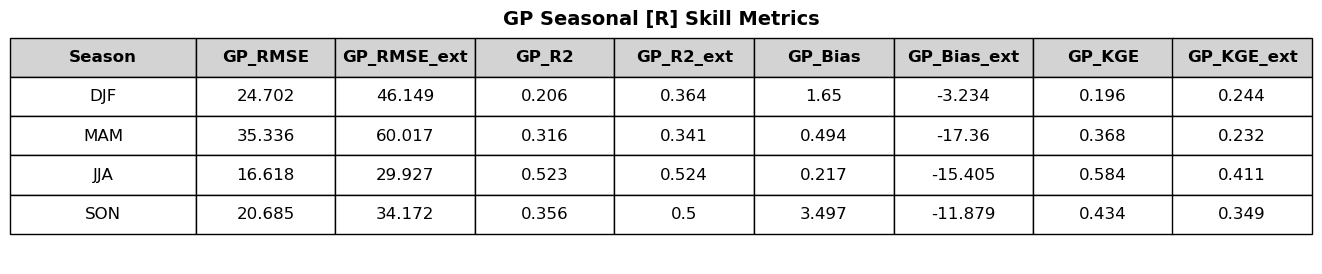

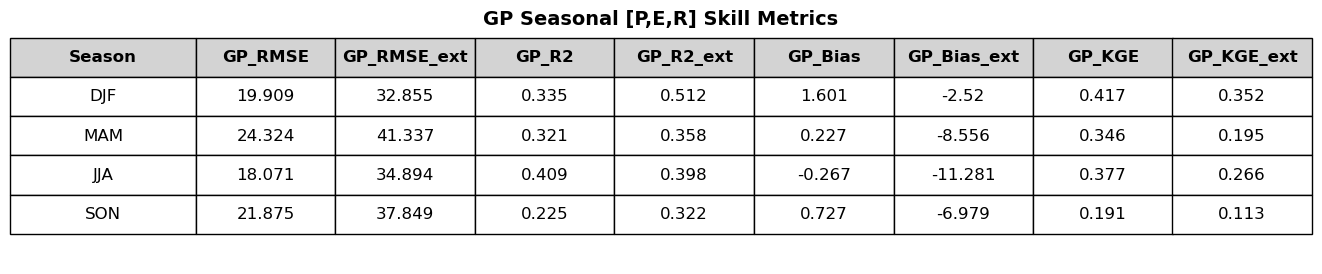

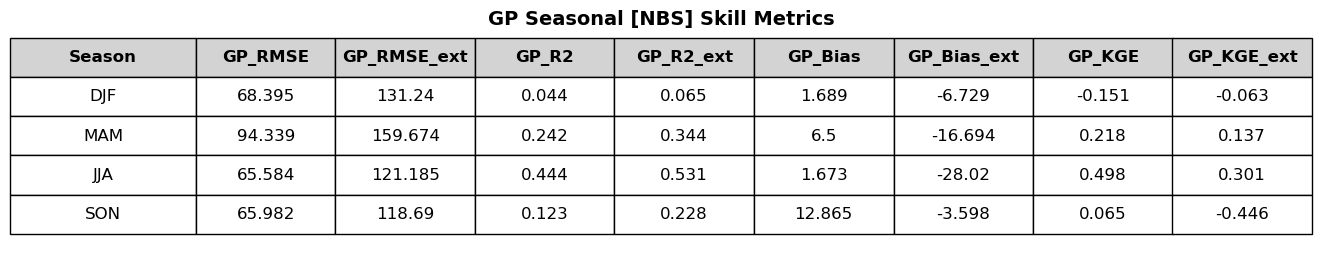

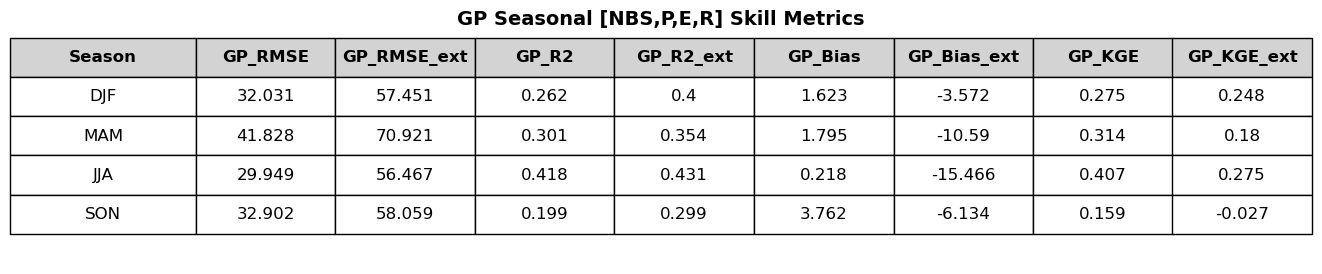

In [ ]:
lakes = ['superior', 'michigan-huron', 'erie', 'ontario']
models = ['GP']

component_configs = [
    (['precipitation'], "GP Seasonal [P] Skill Metrics"),
    (['evaporation'], "GP Seasonal [E] Skill Metrics"),
    (['runoff'], "GP Seasonal [R] Skill Metrics"),
    (['precipitation', 'evaporation', 'runoff'], "GP Seasonal [P,E,R] Skill Metrics"),
    (['nbs'], "GP Seasonal [NBS] Skill Metrics"),
    (['nbs', 'precipitation', 'evaporation', 'runoff'], "GP Seasonal [NBS,P,E,R] Skill Metrics"),
]

selected_metrics = [
    'RMSE', 'RMSE_ext',
    'R2', 'R2_ext',
    'Bias', 'Bias_ext',
    'KGE', 'KGE_ext'
]

seasons = ['DJF', 'MAM', 'JJA', 'SON']

# =========================
# MAIN LOOP (WITH PIVOT)
# =========================
for components, title in component_configs:

    seasonal_results = []

    for season in seasons:
        df_season = df[df['season'] == season]

        if df_season.empty:
            continue

        for model in models:

            skill = compute_skill(
                df_season,
                lakes=lakes,
                components=components,
                model=model,
                metrics=selected_metrics,
                date_col='forecast_month_dt'
            )

            skill['Season'] = season
            seasonal_results.append(skill)

    df_seasonal = pd.DataFrame(seasonal_results)

    if df_seasonal.empty:
        continue

    # -------------------------
    # PIVOT TABLE
    # -------------------------
    df_pivot = df_seasonal.pivot(index='Season', columns='Model')

    # flatten multi-index columns
    df_pivot.columns = [f"{model}_{metric}" for metric, model in df_pivot.columns]

    df_pivot = df_pivot.reset_index()

    # enforce season order
    df_pivot['Season'] = pd.Categorical(df_pivot['Season'], categories=seasons, ordered=True)
    df_pivot = df_pivot.sort_values('Season')

    # -------------------------
    # PLOT
    # -------------------------
    plot_styled_table(
        df_pivot,
        title=title
    )

In [ ]:
df_all = df_combined.copy()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# =========================================================
# 1. PREPROCESSING: make metrics comparable
# =========================================================
def prepare_skill_data(df, metrics):
    """
    Converts skill metrics so that higher = better for all columns.
    """

    df_plot = df.copy()

    for m in metrics:
        if m in ['RMSE', 'CRPS', 'Bias']:
            # lower is better → invert
            df_plot[m] = -df_plot[m]

        elif m == 'VarRatio':
            # best is 1 → penalize deviation
            df_plot[m] = -np.abs(df_plot[m] - 1)

        # R2, NSE, KGE already: higher = better

    df_plot = df_plot.set_index('Model')

    return df_plot


# =========================================================
# 2. NORMALIZATION (optional but recommended for heatmaps)
# =========================================================
def normalize_columns(df):
    """
    Min-max normalize each column to [0, 1].
    """
    return (df - df.min()) / (df.max() - df.min())


# =========================================================
# 3. HEATMAP PLOTTING FUNCTION
# =========================================================
def plot_skill_heatmap(df, title, annotate=True, normalize=True):
    """
    Publication-quality heatmap for model skill comparison.
    """

    sns.set_theme(style="white")

    plt.rcParams.update({
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.labelsize": 12
    })

    # -------------------------
    # prepare data
    # -------------------------
    df_plot = df.copy()

    if normalize:
        df_plot = normalize_columns(df_plot)
        cbar_label = "Normalized Skill (higher = better)"
    else:
        cbar_label = "Skill (transformed)"

    # -------------------------
    # create figure
    # -------------------------
    fig, ax = plt.subplots(figsize=(10, 4))

    sns.heatmap(
        df_plot,
        cmap="viridis",
        linewidths=0.5,
        linecolor="lightgray",
        annot=df.round(2) if annotate else False,
        fmt="",
        cbar_kws={"label": cbar_label},
        ax=ax
    )

    # -------------------------
    # styling
    # -------------------------
    ax.set_title(title, pad=12)
    ax.set_xlabel("Metric")
    ax.set_ylabel("Model")

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()


# =========================================================
# 4. MAIN WORKFLOW (USES YOUR df_all)
# =========================================================
def run_heatmap(df_all, selected_metrics, title="Skill Comparison Heatmap"):
    """
    Full pipeline: preprocess + plot.
    """

    df_prepared = prepare_skill_data(df_all, selected_metrics)
    plot_skill_heatmap(df_prepared, title=title, normalize=True)


# =========================================================
# 5. USAGE EXAMPLE
# =========================================================
# Assuming df_all comes from your compute_skill loop:

# df_all = pd.DataFrame(results)
# df_all = df_all[['Model'] + selected_metrics]

run_heatmap(
    df_all=df_all,
    selected_metrics=selected_metrics,
    title="All Lakes Skill Comparison (P,E,R configuration)"
)

KeyError: 'RMSE'